# Imports

In [66]:
import os
import pickle
import re
import shutil
import sys
sys.path.append(os.path.dirname(os.getcwd()))
from itertools import product
from scipy.stats import norm
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import yaml
from matplotlib.backends.backend_pdf import PdfPages
from tools import load_npy, load_yaml_as_df, load_pkl, exist_metric, exist_stf_metric, inverse_stf_metrics, keep_split, is_full_group

plt.style.use('default')
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
plt.rc('font', family='Arial')
matplotlib.rcParams['mathtext.fontset'] = 'stix'
matplotlib.rcParams['font.size'] = 10

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# Varying # inner steps

## load data

In [67]:
save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/stats_ML3'
log_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/logs'

baselines = pd.read_csv(f'{log_root}/baselines_chosen.csv')
finetunes_all = pd.read_csv(f'{save_root}/finetune_all_results.csv')
finetunes_all = finetunes_all[
    finetunes_all.meta_lr.isin([0.01, 0.02, 0.05, 0.1, 0.2]) &
    finetunes_all.meta_inner_steps.isin([1, 2, 3, 4, 5]) &
    finetunes_all.num_tasks.isin([1, 2, 3, 4, 5])
]

base = baselines.copy()
base = base[
    ((base.data_id == 'ETTh1') & (base.model == 'TQNet')) |
    ((base.data_id == 'ETTh2') & (base.model == 'TQNet')) |
    ((base.data_id == 'ETTm1') & (base.model == 'TQNet')) |
    ((base.data_id == 'ETTm2') & (base.model == 'TQNet')) |
    ((base.data_id == 'ECL') & (base.model == 'TQNet')) |
    ((base.data_id == 'Weather') & (base.model == 'TQNet'))
]
base['meta_inner_steps'] = 0

hps = finetunes_all.copy()
hps = hps[
    (hps.meta_type == 'all')
]
hps = hps[
    ((hps.data_id == 'ETTh1') & (hps.model == 'TQNet')) |
    ((hps.data_id == 'ETTh2') & (hps.model == 'TQNet')) |
    ((hps.data_id == 'ETTm1') & (hps.model == 'TQNet')) |
    ((hps.data_id == 'ETTm2') & (hps.model == 'TQNet')) |
    ((hps.data_id == 'ECL') & (hps.model == 'TQNet')) |
    ((hps.data_id == 'Weather') & (hps.model == 'TQNet'))
]

In [68]:
for inner_step in [1, 2, 3, 4, 5]:
    print(hps[(hps.data_id == 'ECL') & (hps.model == 'TQNet') & (hps.meta_inner_steps == inner_step)].pred_len.nunique())
    print(hps[(hps.data_id == 'Weather') & (hps.model == 'TQNet') & (hps.meta_inner_steps == inner_step)].pred_len.nunique())
    print()

4
4

4
4

4
4

4
4

4
4



## preprocess main

In [69]:
df2 = hps.copy()

min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'meta_inner_steps'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]

df3 = base.copy()

columns = ['model', 'data_id', 'pred_len', 'meta_inner_steps', 'mse', 'mae']
df3 = df3[columns]
df2 = df2[columns]

df_step = pd.concat([df3, df2], axis=0)

dst_order = ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'ECL', 'Weather']
df_step['data_id'] = pd.Categorical(df_step['data_id'], categories=dst_order, ordered=True)

# df_step['alpha'] = df_step['alpha'].astype(float)

df_step_avg = df_step.groupby(['model', 'data_id', 'meta_inner_steps']).mean(numeric_only=True).reset_index()
df_step_avg['pred_len'] = 'Avg'

df_step = pd.concat([df_step, df_step_avg]).reset_index(drop=True)
df_step.sort_values(by=['model', 'data_id', 'meta_inner_steps', 'pred_len'], inplace=True)

df_step_avg

/tmp/ipykernel_482105/908301019.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_step_avg = df_step.groupby(['model', 'data_id', 'meta_inner_steps']).mean(numeric_only=True).reset_index()


,model,data_id,meta_inner_steps,pred_len,mse,mae
0,TQNet,ETTh1,0,Avg,0.448900,0.438991
1,TQNet,ETTh1,1,Avg,0.435161,0.434502
2,TQNet,ETTh1,2,Avg,0.433061,0.433697
3,TQNet,ETTh1,3,Avg,0.435988,0.432123
4,TQNet,ETTh1,4,Avg,0.435357,0.434230
5,TQNet,ETTh1,5,Avg,0.436902,0.433062
6,TQNet,ETTh2,0,Avg,0.374594,0.400312
7,TQNet,ETTh2,1,Avg,0.368930,0.397033
8,TQNet,ETTh2,2,Avg,0.368644,0.397044
9,TQNet,ETTh2,3,Avg,0.368834,0.396628


## write to table

In [35]:
# 首先找出每个data_id的最小值和次小值位置
def find_best_and_second_best(df, data_ids, metric):
    best_worst_dict = {}
    
    for data_id in data_ids:
        data_subset = df[df['data_id'] == data_id]
        values = data_subset[metric].values
        inner_steps = data_subset['meta_inner_steps'].values
        
        # 找到最小值和次小值的索引
        sorted_indices = np.argsort(values)
        best_inner_step = inner_steps[sorted_indices[0]]
        second_best_inner_step = inner_steps[sorted_indices[1]]
        
        best_worst_dict[data_id] = {
            'best': best_inner_step,
            'second_best': second_best_inner_step
        }
    
    return best_worst_dict

# 生成latex表格
def generate_latex_table(df_step, data_ids=['ECL', 'Weather']):
    # 找出MSE和MAE的最小值和次小值位置
    mse_ranks = find_best_and_second_best(df_step, data_ids, 'mse')
    mae_ranks = find_best_and_second_best(df_step, data_ids, 'mae')
    
    contents = []
    
    for inner_step in [0, 1, 2, 3, 4, 5]:
        line = f"{inner_step} "
        
        for data_id in data_ids:
            _df = df_step[
                (df_step['meta_inner_steps'] == inner_step) &
                (df_step['data_id'] == data_id) &
                (df_step['pred_len'] == 'Avg')
            ]
            
            mse_val = _df['mse'].values[0]
            mae_val = _df['mae'].values[0]
            
            # 格式化MSE值
            if inner_step == mse_ranks[data_id]['best']:
                mse_str = f"\\bst{{{mse_val:.4f}}}"
            elif inner_step == mse_ranks[data_id]['second_best']:
                mse_str = f"\\subbst{{{mse_val:.4f}}}"
            else:
                mse_str = f"{mse_val:.4f}"
            
            # 格式化MAE值
            if inner_step == mae_ranks[data_id]['best']:
                mae_str = f"\\bst{{{mae_val:.4f}}}"
            elif inner_step == mae_ranks[data_id]['second_best']:
                mae_str = f"\\subbst{{{mae_val:.4f}}}"
            else:
                mae_str = f"{mae_val:.4f}"
            
            line += f"& {mse_str} & {mae_str} "
        
        line += r"\\"
        contents.append(line)
    
    return "\n".join(contents)

latex_table = generate_latex_table(df_step_avg)
print(latex_table)


0 & 0.1750 & 0.2655 & 0.2457 & 0.2703 \\
1 & \subbst{0.1647} & \bst{0.2567} & \subbst{0.2427} & 0.2682 \\
2 & \bst{0.1647} & \subbst{0.2568} & 0.2427 & 0.2683 \\
3 & 0.1649 & 0.2570 & 0.2431 & 0.2687 \\
4 & 0.1656 & 0.2572 & 0.2428 & \subbst{0.2681} \\
5 & 0.1654 & 0.2571 & \bst{0.2426} & \bst{0.2681} \\


## plot main

/tmp/ipykernel_482105/1046015547.py:14: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(x=x, y='mse', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")
/tmp/ipykernel_482105/1046015547.py:34: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(x=x, y='mae', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['^', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")
/tmp/ipykernel_482105/1046015547.py:14: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(x=x, y='mse', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")
/tmp/ipykernel_482105/1046015547.py:34: Use

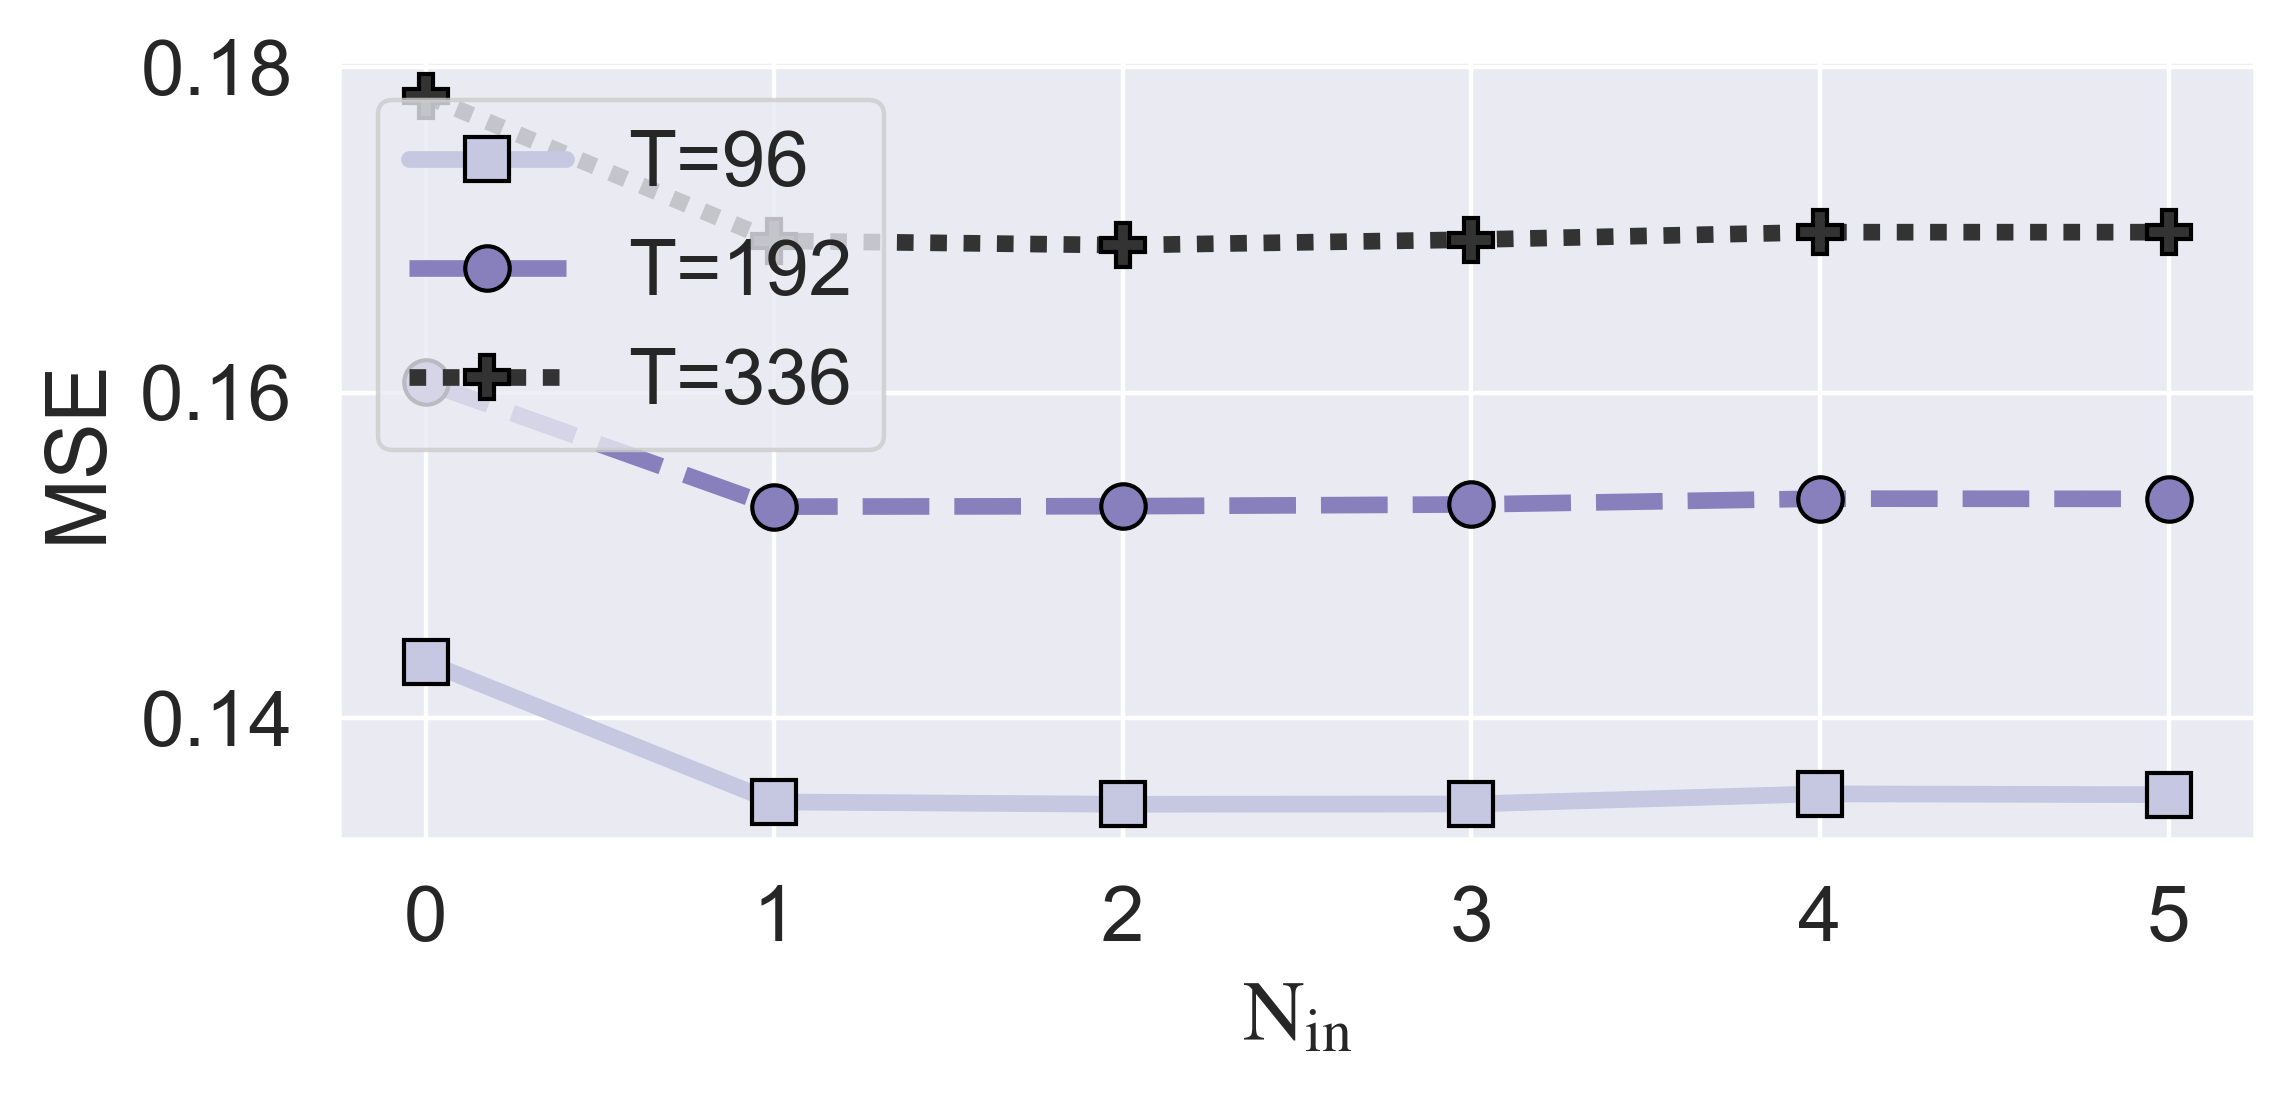

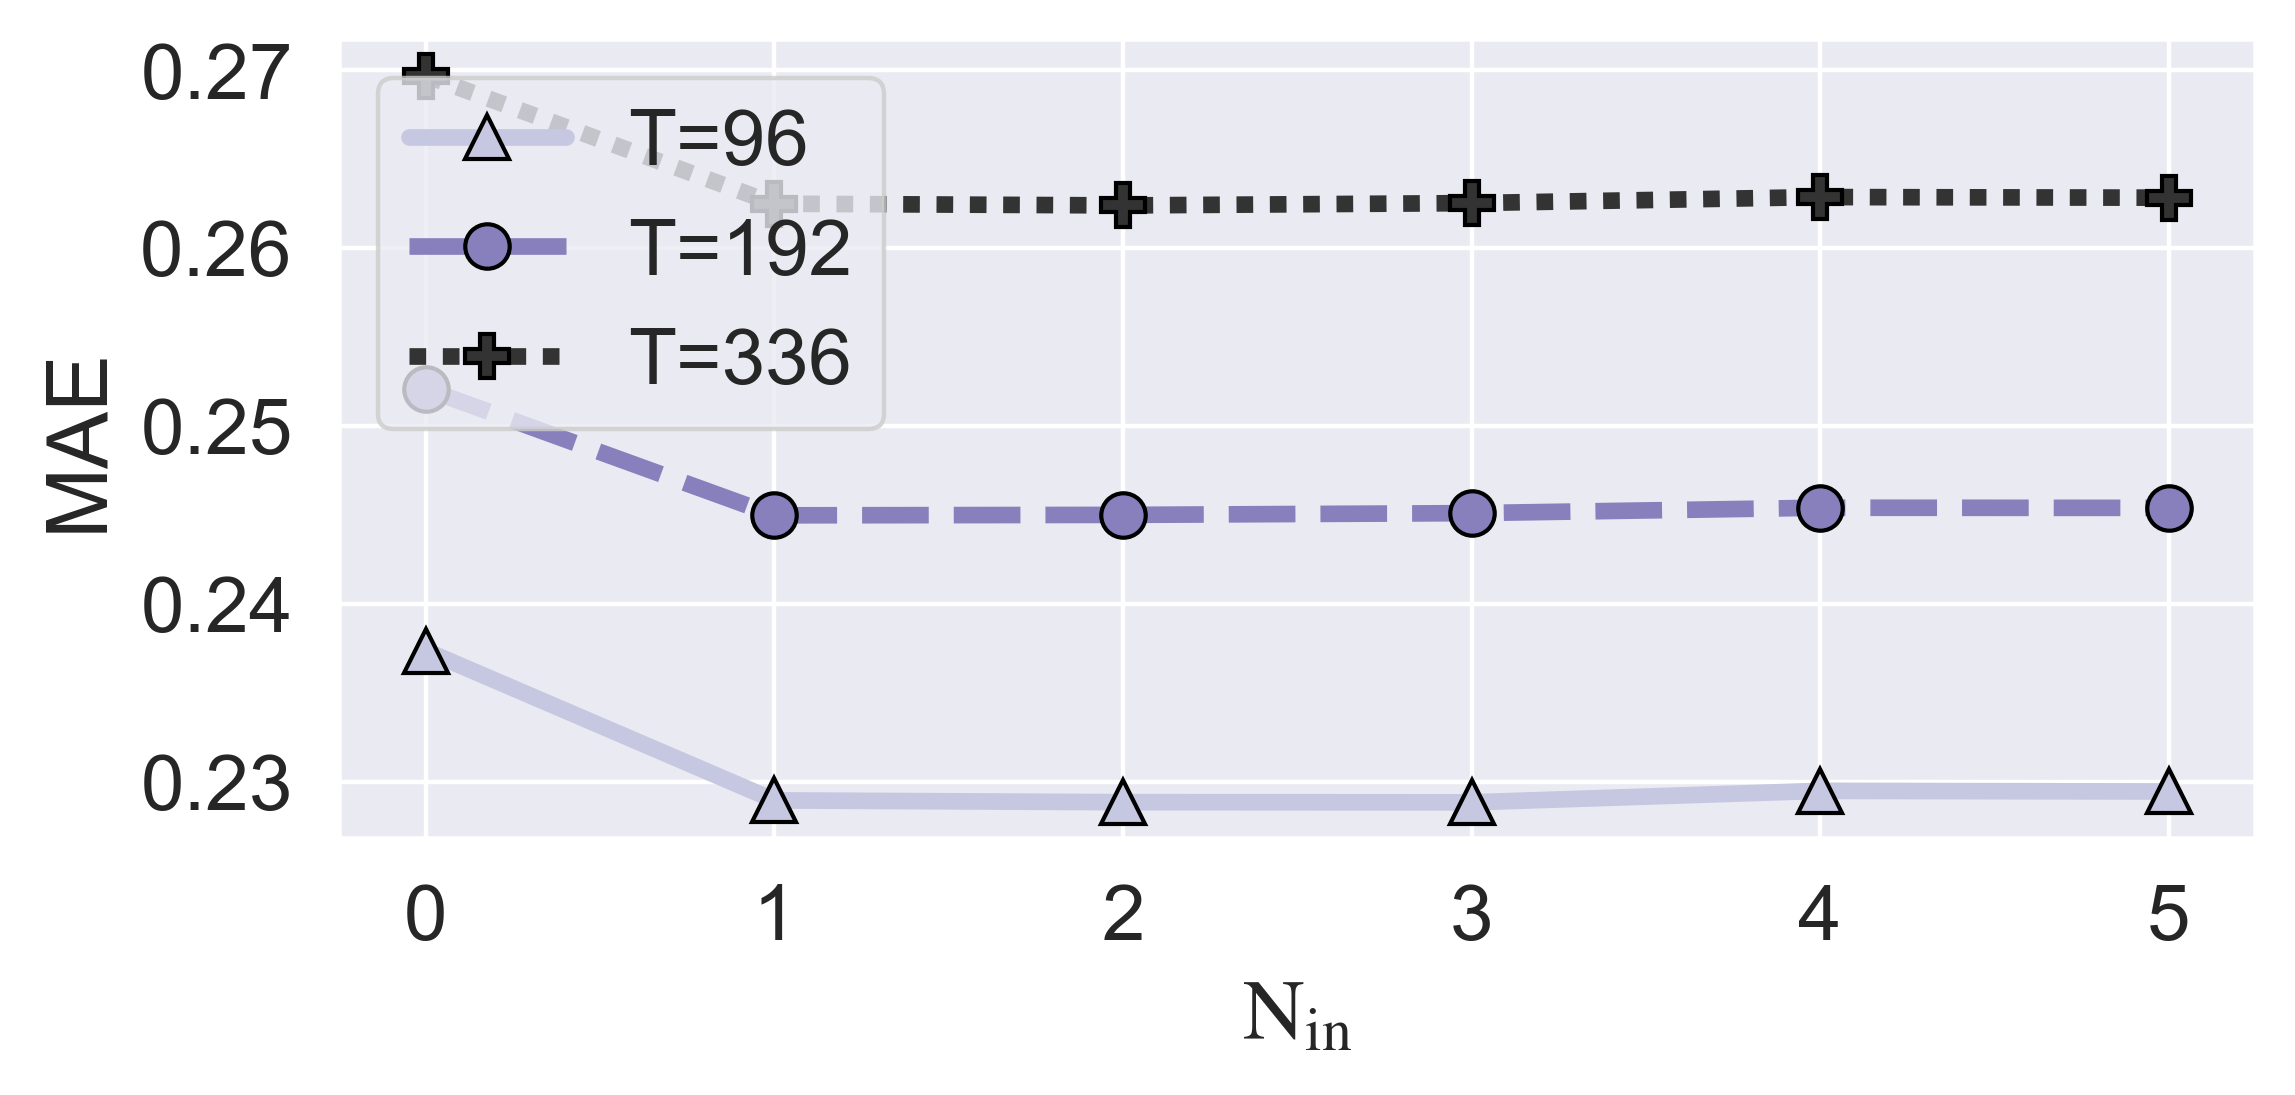

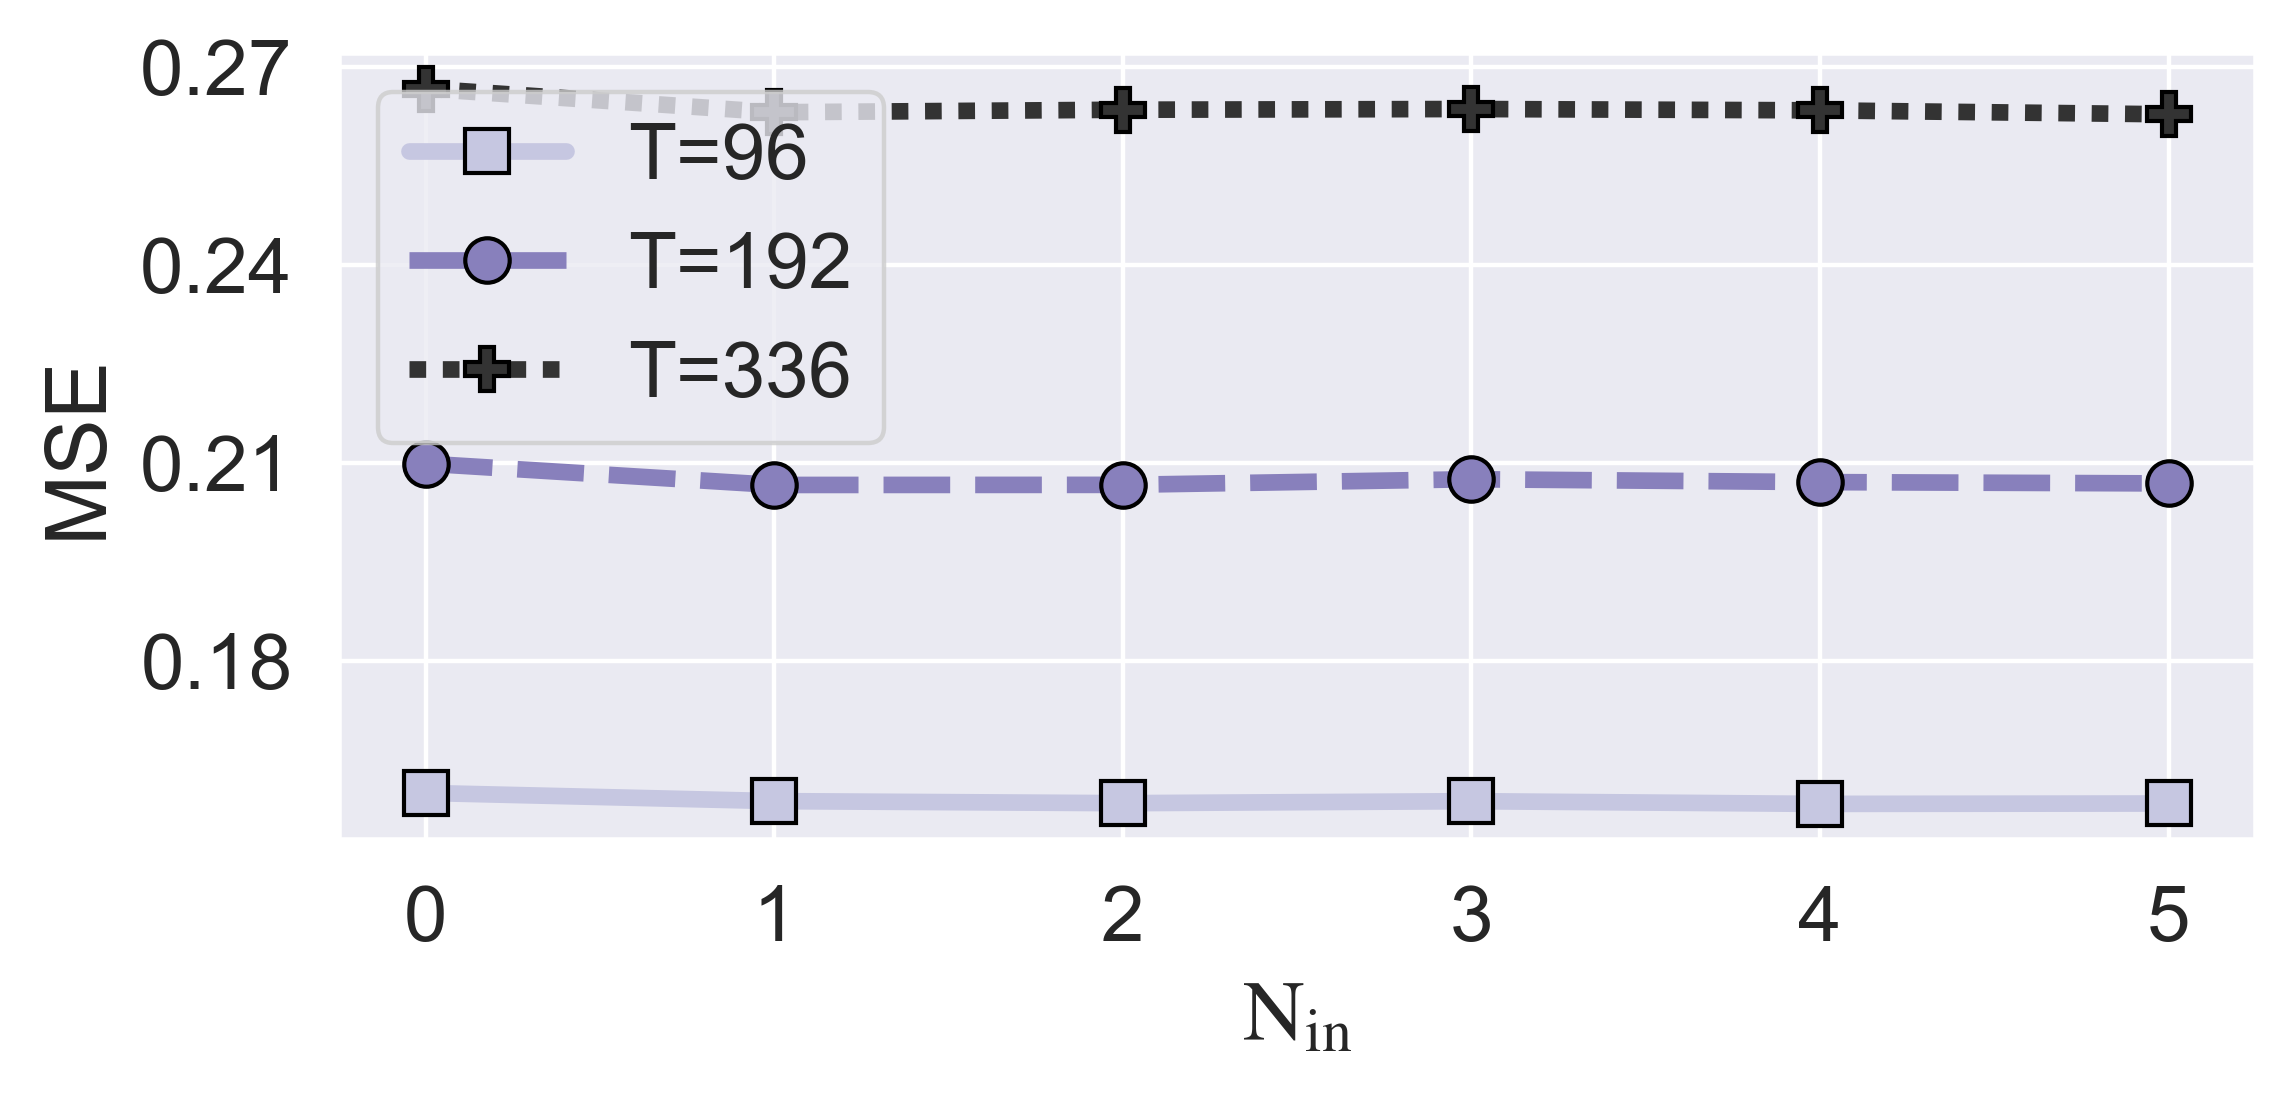

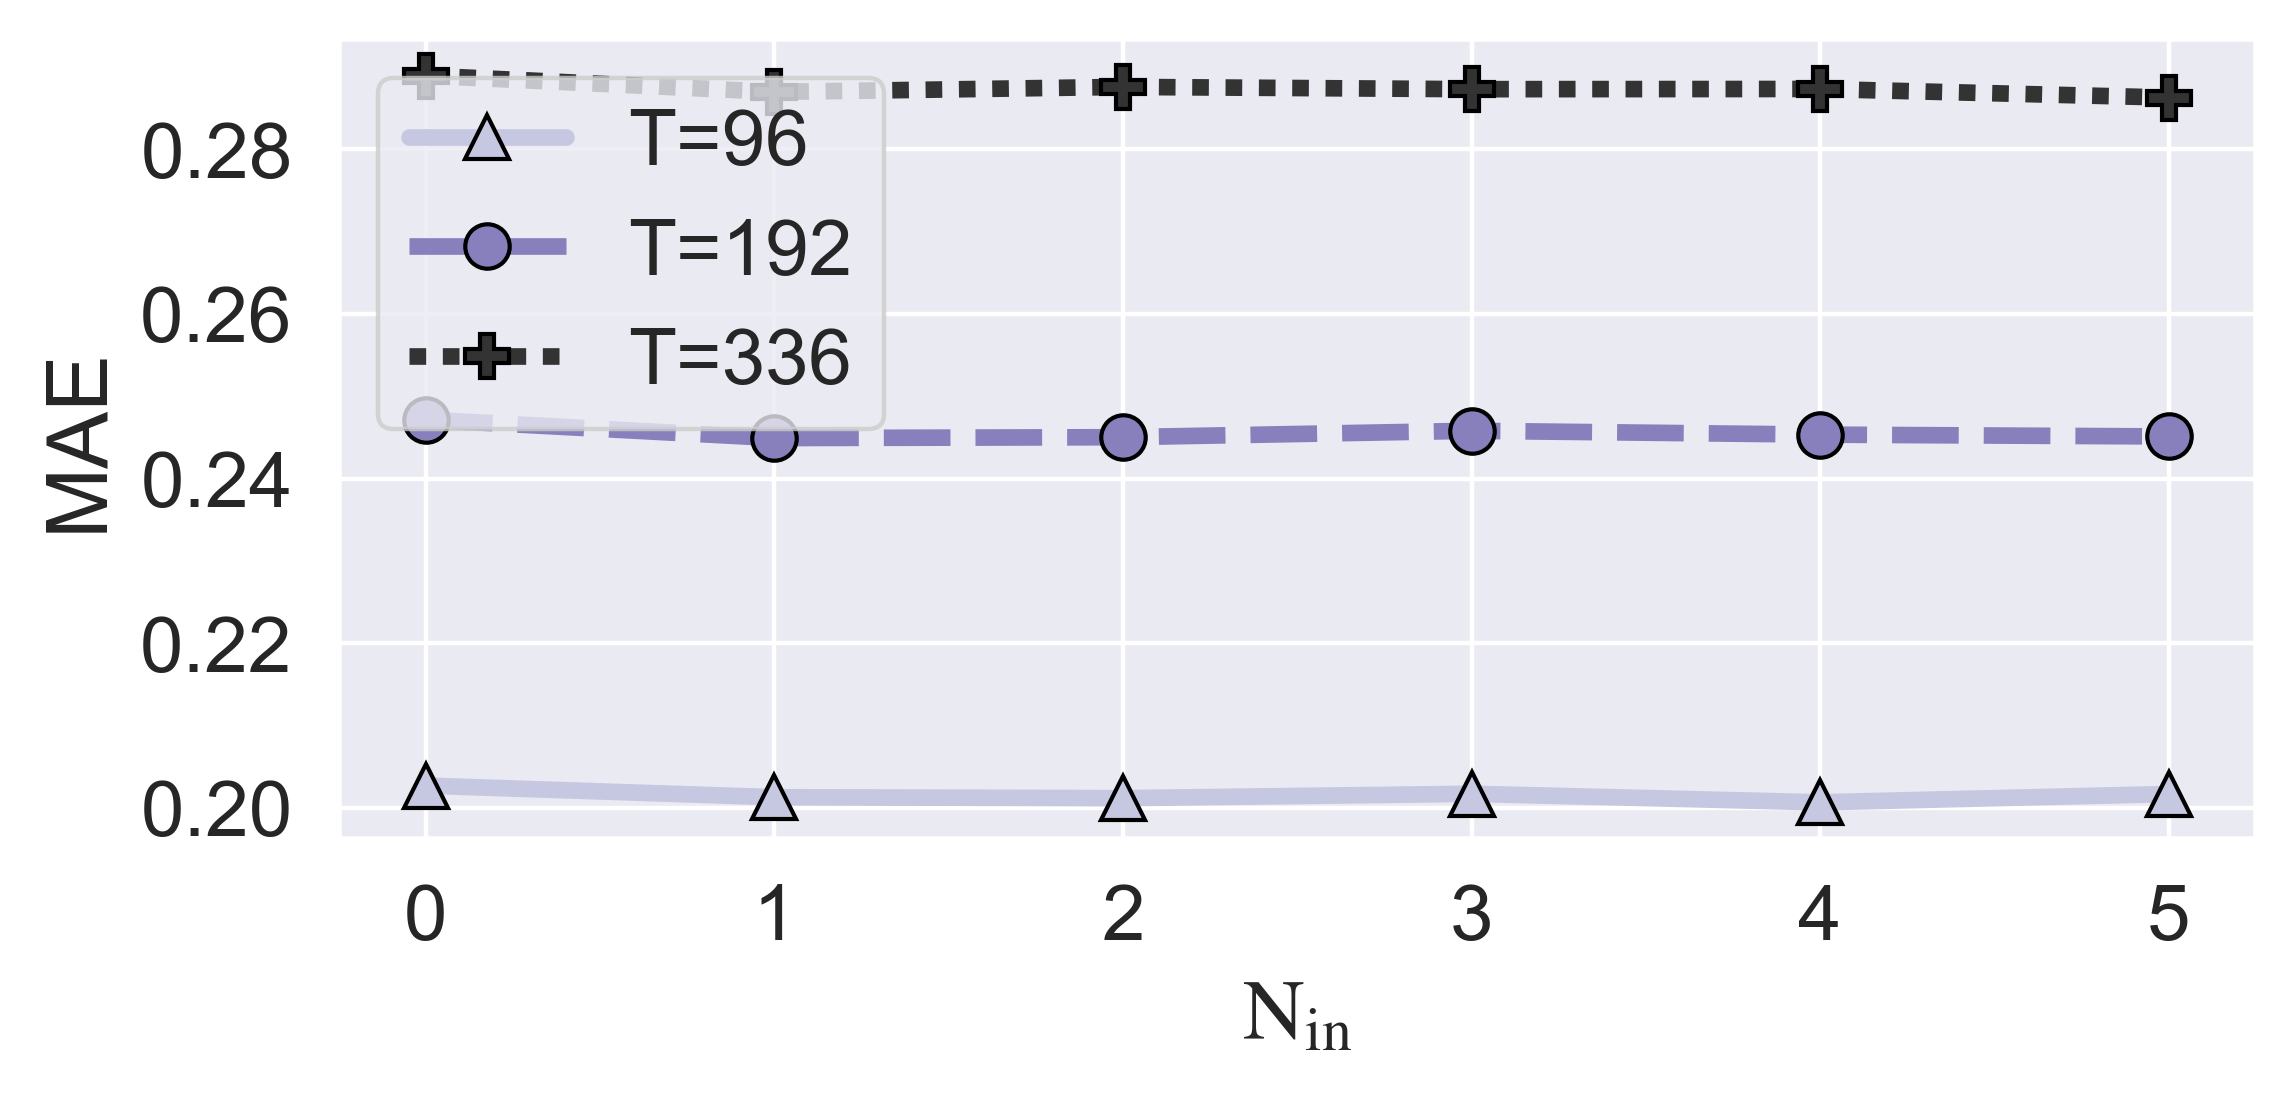

In [93]:
def plot(dataset, figure_name='figure', x='labda', x_name=r'$\lambda$', hue='p_noise', ytick1=None, ytick2=None, ypad1=None, ypad2=None, loc='upper left'):
    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    # dataset = dataset.sort_values(by=x)
    # dataset[x] = dataset[x].astype(str)

    f = plt.figure(dpi=400, figsize=(6,3)) # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1,1,1)
    sns.lineplot(x=x, y='mse', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")

    ax = plt.gca()
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=[r'T=96', r'T=192', r'T=336'], ncol=1, loc=loc)
    # plt.legend(handles=handles, ncol=2, loc=legend_location)
    if ytick1:
        plt.yticks(ytick1)
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    plt.ylabel('MSE')
    plt.xlabel(x_name)
    plt.tight_layout()
    with PdfPages(f"{figure_name}_MSE.pdf") as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)
    # plt.show()

    f = plt.figure(dpi=400, figsize=(6,3)) # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1,1,1)
    sns.lineplot(x=x, y='mae', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['^', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")

    ax = plt.gca()
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=[r'T=96', r'T=192', r'T=336'], ncol=1, loc=loc)
    # plt.yscale('log')
    if ytick2:
        plt.yticks(ytick2)
    if ypad2:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad2))  # 小数点后3位数间隔。
    plt.ylabel('MAE')
    plt.xlabel(x_name)
    plt.tight_layout()
    with PdfPages(f"{figure_name}_MAE.pdf") as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)
    # plt.show()


save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/figure_ML3'
os.makedirs(f"{save_root}/hparam", exist_ok=True)

datap = df_step.copy()
datap_ = datap[datap.data_id == 'ECL']
datap_ = datap_[datap_.pred_len.isin([96, 192, 336])]

save_name = f"{save_root}/hparam/ECL_N_in"
plot(datap_, x='meta_inner_steps', hue='pred_len', figure_name=save_name, x_name=r"$\mathrm{N}_\mathrm{in}$")


datap_ = datap[datap.data_id == 'Weather']
datap_ = datap_[datap_.pred_len.isin([96, 192, 336])]

save_name = f"{save_root}/hparam/Weather_N_in"
plot(datap_, x='meta_inner_steps', hue='pred_len', figure_name=save_name, x_name=r"$\mathrm{N}_\mathrm{in}$", ypad1=0.03)

## preprocess all

In [393]:
df2 = hps.copy()

df2 = df2[
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.7) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm1') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTm2') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTm2') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTm2') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.0001) & (df2.data_id == 'ETTm2') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.9) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh1') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.00005) & (df2.data_id == 'ETTh2') & (df2.pred_len == 96) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.6) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh2') & (df2.pred_len == 192) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 0.8) & (df2.learning_rate == 0.0005) & (df2.data_id == 'ETTh2') & (df2.pred_len == 336) & (df2.model == 'Fredformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.0001) & (df2.data_id == 'ETTh2') & (df2.pred_len == 720) & (df2.model == 'Fredformer')) |
    
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL') & (df2.pred_len == 96) & (df2.model == 'iTransformer')) |
    ((df2.rank_ratio == 0.5) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL') & (df2.pred_len == 192) & (df2.model == 'iTransformer')) |
    ((df2.rank_ratio == 1.0) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL') & (df2.pred_len == 336) & (df2.model == 'iTransformer')) |
    # ((df2.rank_ratio == 0.3) & (df2.learning_rate == 0.001) & (df2.data_id == 'ECL') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    ((df2.rank_ratio == 0.3) & (df2.data_id == 'ECL') & (df2.pred_len == 720) & (df2.model == 'iTransformer')) |
    
    # ((df2.rank_ratio == 0.1) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather') & (df2.pred_len == 96) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.1) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather') & (df2.pred_len == 192) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather') & (df2.pred_len == 336) & (df2.model == 'FreTS')) |
    # ((df2.rank_ratio == 0.3) & (df2.learning_rate == 0.001) & (df2.data_id == 'Weather') & (df2.pred_len == 720) & (df2.model == 'FreTS'))
    ((df2.rank_ratio == 0.1) & (df2.data_id == 'Weather') & (df2.pred_len == 96) & (df2.model == 'FreTS')) |
    ((df2.rank_ratio == 0.1) & (df2.data_id == 'Weather') & (df2.pred_len == 192) & (df2.model == 'FreTS')) |
    ((df2.rank_ratio == 0.3) & (df2.data_id == 'Weather') & (df2.pred_len == 336) & (df2.model == 'FreTS')) |
    ((df2.rank_ratio == 0.3) & (df2.data_id == 'Weather') & (df2.pred_len == 720) & (df2.model == 'FreTS'))
]
# 按data去给一个alpha


min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'alpha'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]
df2['data_id'] = df2['data_id'].apply(lambda x: x.replace('', ''))

df3 = base.copy()
df3['rank_ratio'] = 1.0

columns = ['model', 'data_id', 'pred_len', 'alpha', 'mse', 'mae', 'rank_ratio', 'learning_rate']
df3 = df3[columns]
df2 = df2[columns]

df_step = pd.concat([df3, df2], axis=0)

dst_order = ['ETTm1', 'ETTm2', 'ETTh1', 'ETTh2', 'ECL', 'Weather']
df_step['data_id'] = pd.Categorical(df_step['data_id'], categories=dst_order, ordered=True)

df_step['alpha'] = df_step['alpha'].astype(float)
df_step.dropna(inplace=True, thresh=6)

df_step.sort_values(by=['data_id', 'alpha', 'pred_len'], inplace=True)

save_root = '/data/home/Licheng/workspace/TSF-PCA/stats'
columns = ['model', 'data_id', 'pred_len', 'alpha', 'mse', 'mae']
df_step[columns].to_csv(f'{save_root}/hyper_study_alpha.csv', index=False)

df_step.head(10)

,model,data_id,pred_len,alpha,mse,mae,rank_ratio,learning_rate
228,Fredformer,ETTm1,96,0.0,0.326369,0.360869,1.0,0.0001
229,Fredformer,ETTm1,192,0.0,0.365194,0.382132,1.0,0.0001
230,Fredformer,ETTm1,336,0.0,0.395987,0.404369,1.0,0.0001
231,Fredformer,ETTm1,720,0.0,0.459217,0.444342,1.0,0.0001
23197,Fredformer,ETTm1,96,0.1,0.322022,0.358826,1.0,0.0005
23356,Fredformer,ETTm1,192,0.1,0.371666,0.386820,1.0,0.0005
23555,Fredformer,ETTm1,336,0.1,0.396719,0.405975,0.7,0.0005
23689,Fredformer,ETTm1,720,0.1,0.460914,0.444473,0.8,0.0005
23173,Fredformer,ETTm1,96,0.2,0.321644,0.358380,1.0,0.0005
23388,Fredformer,ETTm1,192,0.2,0.371401,0.386566,1.0,0.0005


In [221]:
hps[(hps['data_id'] == 'Weather') & (hps['alpha'] == 1.0) & (hps.pred_len == 96) & (hps.rank_ratio == 0.1)].sort_values(by=['mse'], ascending=True).head(5)
hps[(hps['data_id'] == 'Weather') & (hps['alpha'] == 1.0) & (hps.pred_len == 192) & (hps.rank_ratio == 0.1)].sort_values(by=['mse'], ascending=True).head(5)
hps[(hps['data_id'] == 'Weather') & (hps['alpha'] == 1.0) & (hps.pred_len == 336) & (hps.rank_ratio == 0.3)].sort_values(by=['mse'], ascending=True).head(5)
hps[(hps['data_id'] == 'Weather') & (hps['alpha'] == 1.0) & (hps.pred_len == 720) & (hps.rank_ratio == 0.3)].sort_values(by=['mse'], ascending=True).head(5)

,model,seq_len,pred_len,data_id,learning_rate,alpha,pca_dim,reinit,use_weights,rank_ratio,auxi_loss,batch_size,auxi_type,auxi_mode,lradj,patience,train_epochs,mse,mae,exp_dir
20686,FreTS,96,720,Weather_PCA,0.005,1.0,T,1,0,0.3,MAE,32,pca,basis,type1,3,10,0.370297,0.393778,/data/home/Licheng/workspace/TSF-PCA/results_P...
21329,FreTS,96,720,Weather_PCA,0.004,1.0,T,1,0,0.3,MAE,32,pca,basis,type1,3,10,0.371447,0.397803,/data/home/Licheng/workspace/TSF-PCA/results_P...
21149,FreTS,96,720,Weather_PCA,0.003,1.0,T,1,0,0.3,MAE,32,pca,basis,type1,10,10,0.377764,0.405635,/data/home/Licheng/workspace/TSF-PCA/results_P...
20941,FreTS,96,720,Weather_PCA,0.003,1.0,T,1,0,0.3,MAE,32,pca,basis,type1,3,10,0.377764,0.405635,/data/home/Licheng/workspace/TSF-PCA/results_P...
21164,FreTS,96,720,Weather_PCA,0.002,1.0,T,1,0,0.3,MAE,32,pca,basis,type1,3,10,0.398846,0.427975,/data/home/Licheng/workspace/TSF-PCA/results_P...


## plot all

In [ ]:
def plot(df, save_dir, figure_name='hpsram-study', x='lambda', x_name=r'$\alpha$', ytick1=None, ytick2=None, ypad1=0.005, ypad2=0.005, ylim1=None, ylim2=None):
    legend_location = 'upper right'  # 这里可以根据图的实际情况调节。
    labelsize = 12
    ci = 15
    z = norm.ppf(1 - (1 - ci / 100) / 2)
    errorbar = lambda x: (x.mean() - z * x.std() / np.sqrt(len(x)), x.mean() + z * x.std() / np.sqrt(len(x)))

    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[3], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    f = plt.figure(dpi=400, figsize=(4, 2.5))  # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1, 1, 1)
    sns.lineplot(x=x, y='value', hue='metric', data=df, style='metric', errorbar=errorbar, markers=['X'], linewidth=3, markersize=7, markeredgecolor='k', palette=palette[1:2])
    ax = plt.gca()
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    ax.xaxis.set_major_locator(plt.MultipleLocator(0.2))  # 小数点后3位数间隔。
    leg = plt.legend(ncol=2, loc=legend_location, fontsize=labelsize)
    leg.remove()
    plt.xlabel(x_name)
    # plt.xticks(rotation=90)
    plt.tight_layout()
    plt.ylabel('MSE')
    plt.tick_params(labelsize=labelsize, axis='x')
    print(len(str(ypad1)), str(ypad1))
    if len(str(ypad1)) >= 5:  # 0.001
        plt.tick_params(labelsize=8.7, axis='y')
    else:
        plt.tick_params(labelsize=labelsize, axis='y')
    if ytick1:
        plt.yticks(ytick1)
    plt.xticks([0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
    if ylim1:
        plt.ylim(ylim1)

    with PdfPages(os.path.join(save_dir, f"{figure_name}.pdf")) as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)

dfp = df_step.copy()
# dfp = dfp[dfp.pred_len.isin([192, 336])]

figure_root = '/data/home/Licheng/workspace/TSF-PCA/figure'
save_dir = f'{figure_root}/hyper_study_all'
os.makedirs(save_dir, exist_ok=True)


data_id = 'ETTm1'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.002)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.005)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.003)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.005)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.007)



data_id = 'ETTm2'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.002)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.002)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.003)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.003)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.006)



data_id = 'ETTh1'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.005)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.005)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.005)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.012)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.011)


data_id = 'ETTh2'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.004)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.009)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.011)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.008)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.009)





data_id = 'ECL'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.002)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.004)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.003)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.008)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.005)



data_id = 'Weather'
dfp_ = dfp[(dfp.data_id == data_id)]
dfp_ = dfp_[['pred_len', 'alpha', 'mse', 'mae']]
dfp_ = dfp_.melt(id_vars=['pred_len', 'alpha'], value_vars=['mse', 'mae'], var_name='metric', value_name='value')
dfp_ = dfp_[dfp_.metric == 'mse']

pl = 96
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.022)
pl = 192
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.018)
pl = 336
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.004)
pl = 720
dfp_pl = dfp_[dfp_.pred_len == pl]
plot(dfp_pl, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_{pl}', ypad1=0.006)
plot(dfp_, save_dir=save_dir, x='alpha', x_name=r'$\alpha$', figure_name=f'Fred_{data_id}_alpha_avg', ypad1=0.018)

In [361]:
dfp = df_step.copy()
dfp['lambda'] = 1 - dfp['alpha']
dfp[(dfp.data_id == 'ECL') & (dfp.pred_len == 720)]

,model,data_id,pred_len,alpha,mse,mae,rank_ratio,learning_rate,lambda
435,iTransformer,ECL,720,0.0,0.214451,0.303504,1.0,0.0005,1.0
28060,iTransformer,ECL,720,0.1,0.206687,0.296968,0.3,0.0010,0.9
28011,iTransformer,ECL,720,0.2,0.234212,0.317582,0.3,0.0010,0.8
28015,iTransformer,ECL,720,0.3,0.205887,0.295924,0.3,0.0010,0.7
28685,iTransformer,ECL,720,0.4,0.205676,0.295784,0.3,0.0010,0.6
28069,iTransformer,ECL,720,0.5,0.204935,0.294531,0.3,0.0010,0.5
28514,iTransformer,ECL,720,0.6,0.204421,0.294209,0.3,0.0010,0.4
28364,iTransformer,ECL,720,0.7,0.203587,0.292666,0.3,0.0010,0.3
28027,iTransformer,ECL,720,0.8,0.203276,0.292044,0.3,0.0010,0.2
28603,iTransformer,ECL,720,0.9,0.203909,0.293026,0.3,0.0010,0.1


# Varying # tasks

## load data

In [94]:
save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/stats_ML3'
log_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/logs'

baselines = pd.read_csv(f'{log_root}/baselines_chosen.csv')
finetunes_all = pd.read_csv(f'{save_root}/finetune_all_results.csv')
finetunes_all = finetunes_all[
    finetunes_all.meta_lr.isin([0.01, 0.02, 0.05, 0.1, 0.2]) &
    finetunes_all.meta_inner_steps.isin([1, 2, 3, 4, 5]) &
    finetunes_all.num_tasks.isin([1, 2, 3, 4, 5])
]

base = baselines.copy()
base = base[
    ((base.data_id == 'ETTh1') & (base.model == 'TQNet')) |
    ((base.data_id == 'ETTh2') & (base.model == 'TQNet')) |
    ((base.data_id == 'ETTm1') & (base.model == 'TQNet')) |
    ((base.data_id == 'ETTm2') & (base.model == 'TQNet')) |
    ((base.data_id == 'ECL') & (base.model == 'TQNet')) |
    ((base.data_id == 'Weather') & (base.model == 'TQNet'))
]
base['num_tasks'] = 0

hpt = finetunes_all.copy()
hpt = hpt[
    (hpt.meta_type == 'all')
]
hpt = hpt[
    ((hpt.data_id == 'ETTh1') & (hpt.model == 'TQNet')) |
    ((hpt.data_id == 'ETTh2') & (hpt.model == 'TQNet')) |
    ((hpt.data_id == 'ETTm1') & (hpt.model == 'TQNet')) |
    ((hpt.data_id == 'ETTm2') & (hpt.model == 'TQNet')) |
    ((hpt.data_id == 'ECL') & (hpt.model == 'TQNet')) |
    ((hpt.data_id == 'Weather') & (hpt.model == 'TQNet'))
]

In [95]:
for num_task in [1, 2, 3, 4, 5]:
    print(hpt[(hpt.data_id == 'ECL') & (hpt.model == 'TQNet') & (hpt.num_tasks == num_task)].pred_len.nunique())
    print(hpt[(hpt.data_id == 'Weather') & (hpt.model == 'TQNet') & (hpt.num_tasks == num_task)].pred_len.nunique())
    print()

4
4

4
4

4
4

4
4

4
4



## preprocess main

In [96]:
df2 = hpt.copy()

min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'num_tasks'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]

df3 = base.copy()

columns = ['model', 'data_id', 'pred_len', 'num_tasks', 'mse', 'mae']
df3 = df3[columns]
df2 = df2[columns]

df_task = pd.concat([df3, df2], axis=0)

dst_order = ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'ECL', 'Weather']
df_task['data_id'] = pd.Categorical(df_task['data_id'], categories=dst_order, ordered=True)

# df_step['alpha'] = df_step['alpha'].astype(float)

df_task_avg = df_task.groupby(['model', 'data_id', 'num_tasks']).mean(numeric_only=True).reset_index()
df_task_avg['pred_len'] = 'Avg'

df_task = pd.concat([df_task, df_task_avg]).reset_index(drop=True)
df_task.sort_values(by=['model', 'data_id', 'num_tasks', 'pred_len'], inplace=True)

df_task_avg

/tmp/ipykernel_482105/3836771447.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_task_avg = df_task.groupby(['model', 'data_id', 'num_tasks']).mean(numeric_only=True).reset_index()


,model,data_id,num_tasks,pred_len,mse,mae
0,TQNet,ETTh1,0,Avg,0.448900,0.438991
1,TQNet,ETTh1,1,Avg,0.435568,0.432537
2,TQNet,ETTh1,2,Avg,0.437508,0.435299
3,TQNet,ETTh1,3,Avg,0.434298,0.433917
4,TQNet,ETTh1,4,Avg,0.437961,0.432582
5,TQNet,ETTh1,5,Avg,0.433334,0.431316
6,TQNet,ETTh2,0,Avg,0.374594,0.400312
7,TQNet,ETTh2,1,Avg,0.369170,0.397565
8,TQNet,ETTh2,2,Avg,0.369558,0.397729
9,TQNet,ETTh2,3,Avg,0.370296,0.397787


## write to table

In [65]:
# 首先找出每个data_id的最小值和次小值位置
def find_best_and_second_best(df, data_ids, metric):
    best_worst_dict = {}
    
    for data_id in data_ids:
        data_subset = df[df['data_id'] == data_id]
        values = data_subset[metric].values
        num_task_list = data_subset['num_tasks'].values
        
        # 找到最小值和次小值的索引
        sorted_indices = np.argsort(values)
        best_ntask = num_task_list[sorted_indices[0]]
        second_best_ntask = num_task_list[sorted_indices[1]]
        
        best_worst_dict[data_id] = {
            'best': best_ntask,
            'second_best': second_best_ntask
        }
    
    return best_worst_dict

# 生成latex表格
def generate_latex_table(df_task, data_ids=['ECL', 'Weather']):
    # 找出MSE和MAE的最小值和次小值位置
    mse_ranks = find_best_and_second_best(df_task, data_ids, 'mse')
    mae_ranks = find_best_and_second_best(df_task, data_ids, 'mae')
    
    contents = []
    
    for num_task in [0, 1, 2, 3, 4, 5]:
        line = f"{num_task} "
        
        for data_id in data_ids:
            _df = df_task[
                (df_task['num_tasks'] == num_task) &
                (df_task['data_id'] == data_id) &
                (df_task['pred_len'] == 'Avg')
            ]
            
            mse_val = _df['mse'].values[0]
            mae_val = _df['mae'].values[0]
            
            # 格式化MSE值
            if num_task == mse_ranks[data_id]['best']:
                mse_str = f"\\bst{{{mse_val:.4f}}}"
            elif num_task == mse_ranks[data_id]['second_best']:
                mse_str = f"\\subbst{{{mse_val:.4f}}}"
            else:
                mse_str = f"{mse_val:.4f}"
            
            # 格式化MAE值
            if num_task == mae_ranks[data_id]['best']:
                mae_str = f"\\bst{{{mae_val:.4f}}}"
            elif num_task == mae_ranks[data_id]['second_best']:
                mae_str = f"\\subbst{{{mae_val:.4f}}}"
            else:
                mae_str = f"{mae_val:.4f}"
            
            line += f"& {mse_str} & {mae_str} "
        
        line += r"\\"
        contents.append(line)
    
    return "\n".join(contents)

latex_table = generate_latex_table(df_task_avg)
print(latex_table)


0 & 0.1750 & 0.2655 & 0.2457 & 0.2703 \\
1 & \subbst{0.1650} & \subbst{0.2570} & 0.2428 & 0.2686 \\
2 & 0.1653 & 0.2574 & \bst{0.2427} & 0.2685 \\
3 & \bst{0.1648} & \bst{0.2569} & 0.2428 & \bst{0.2682} \\
4 & 0.1655 & 0.2572 & 0.2429 & 0.2684 \\
5 & 0.1656 & 0.2573 & \subbst{0.2428} & \subbst{0.2683} \\


## plot main

/tmp/ipykernel_482105/1294497722.py:14: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(x=x, y='mse', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")
/tmp/ipykernel_482105/1294497722.py:34: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(x=x, y='mae', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['^', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")
/tmp/ipykernel_482105/1294497722.py:14: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(x=x, y='mse', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")
/tmp/ipykernel_482105/1294497722.py:34: Use

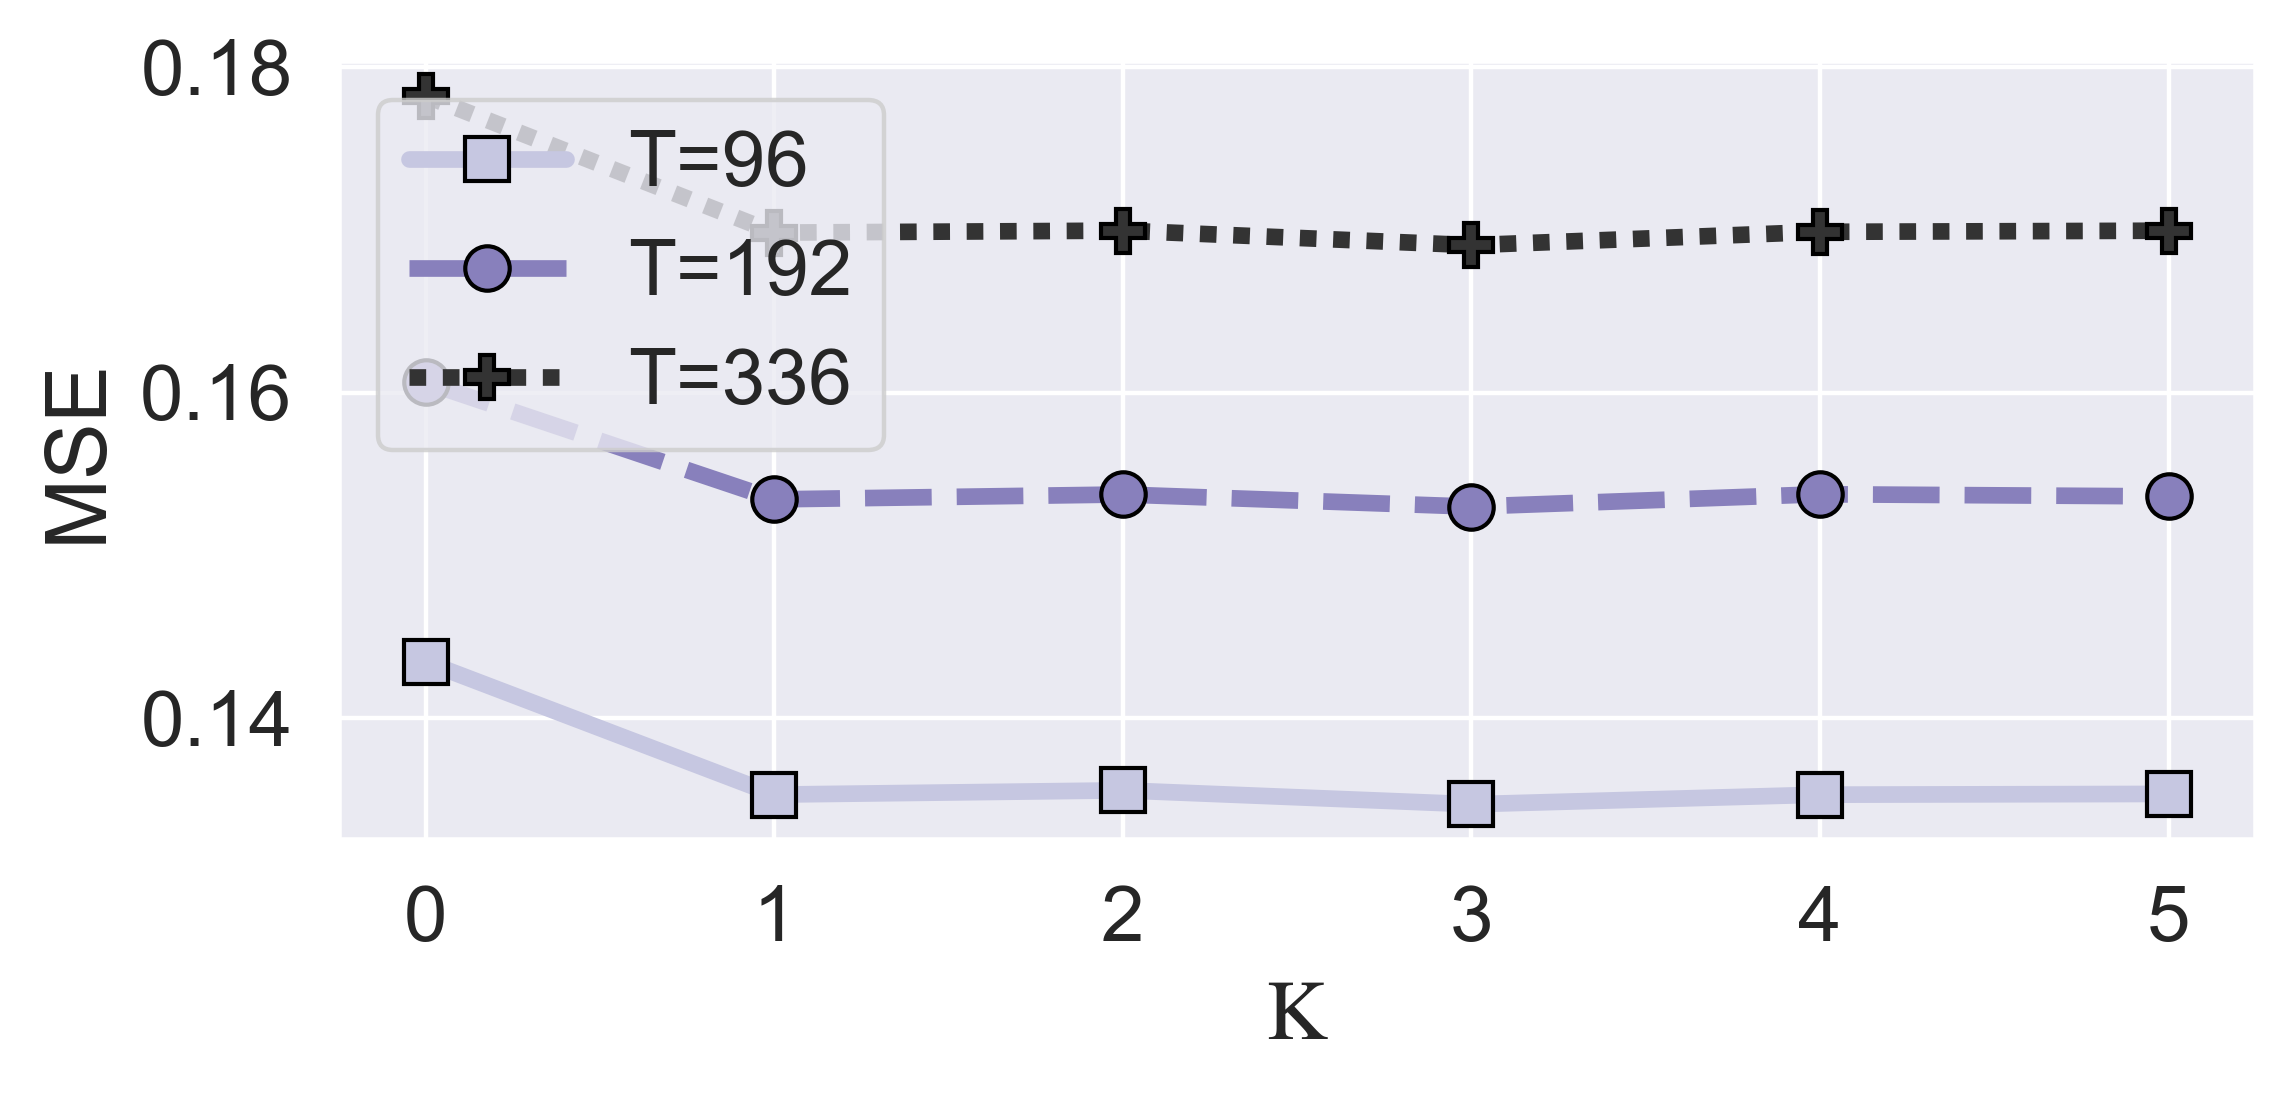

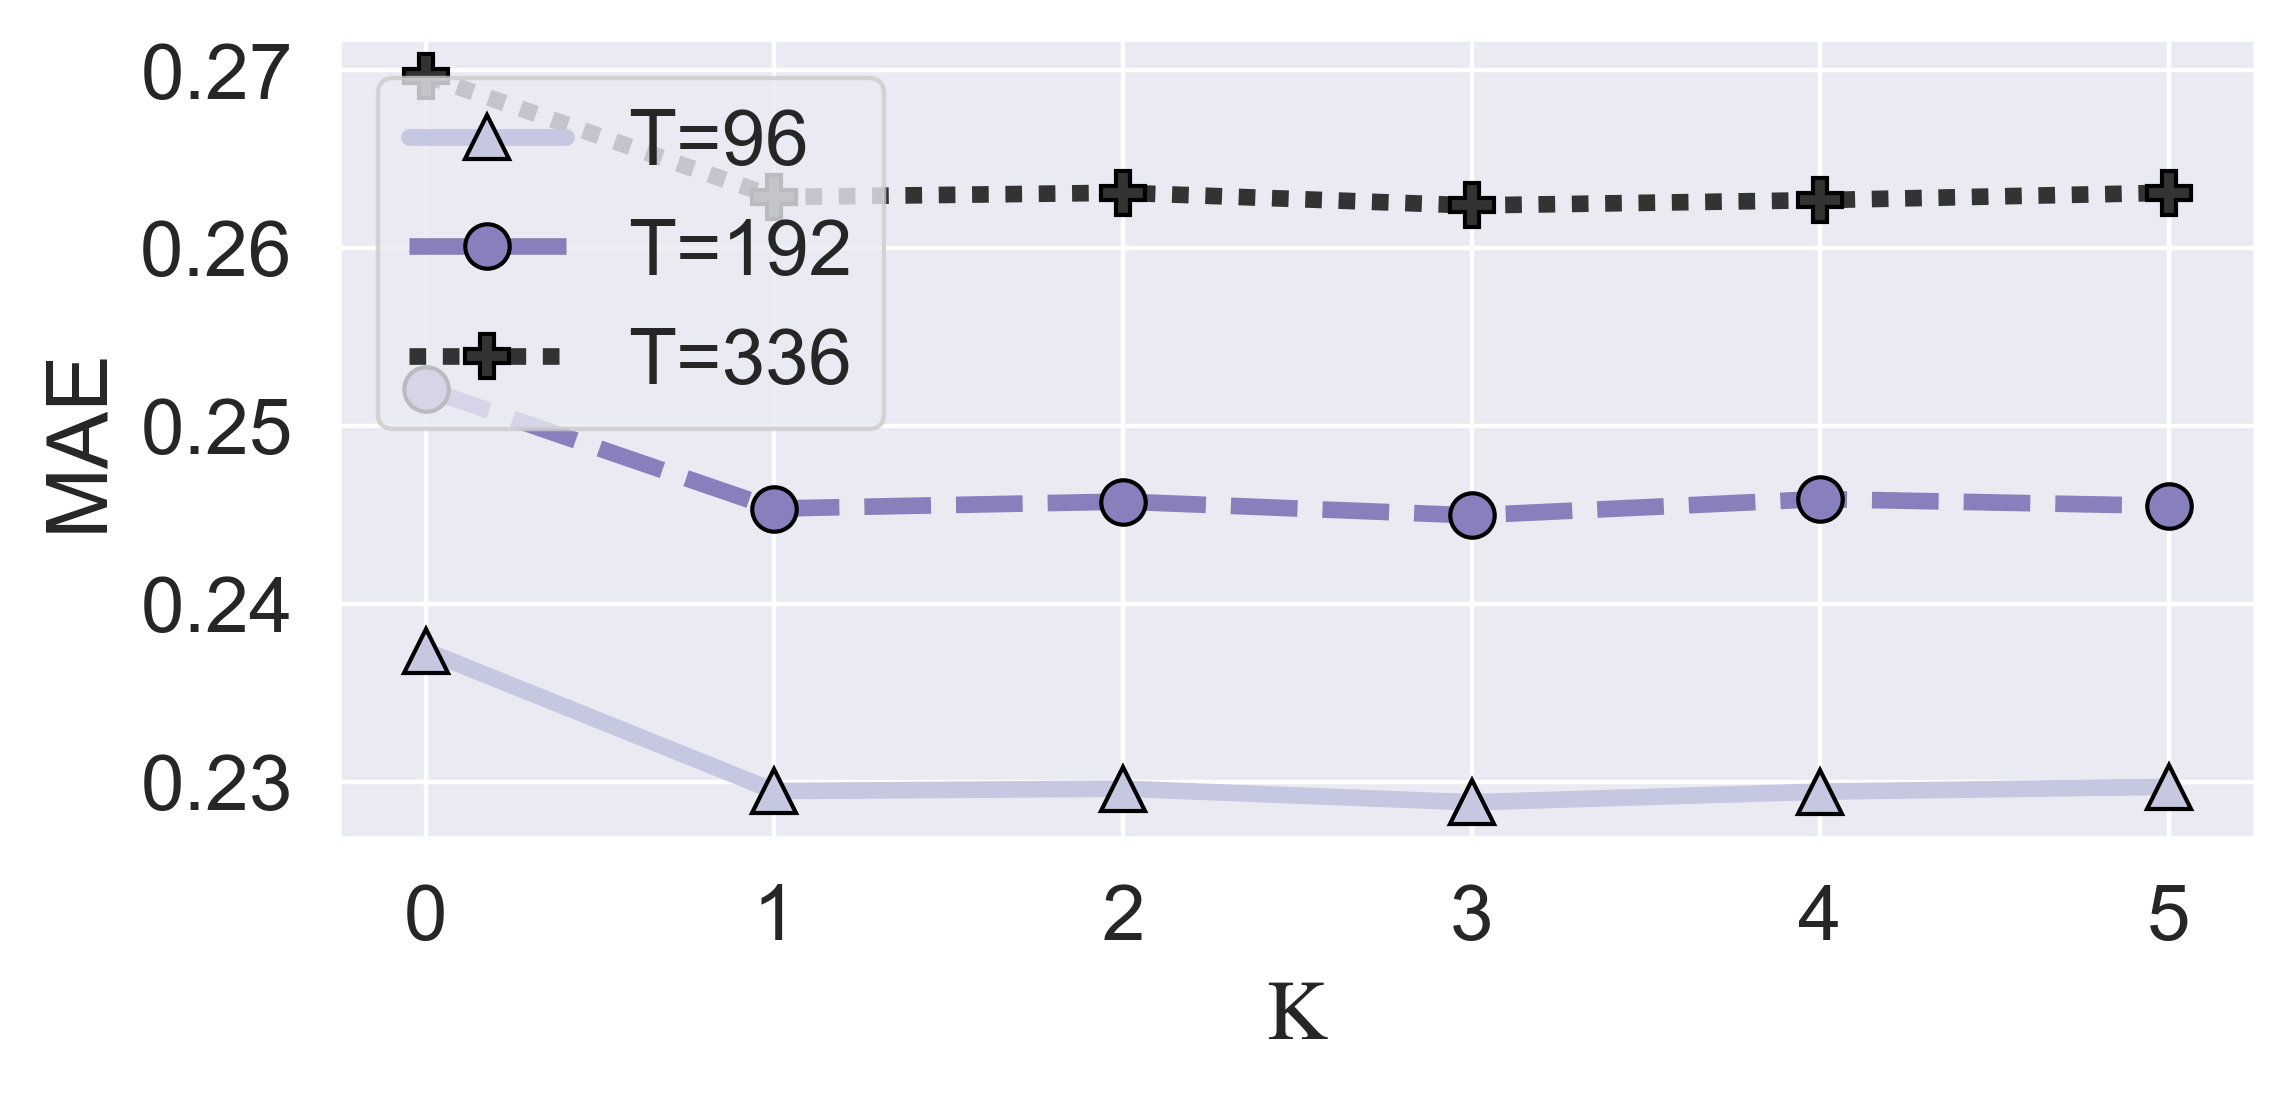

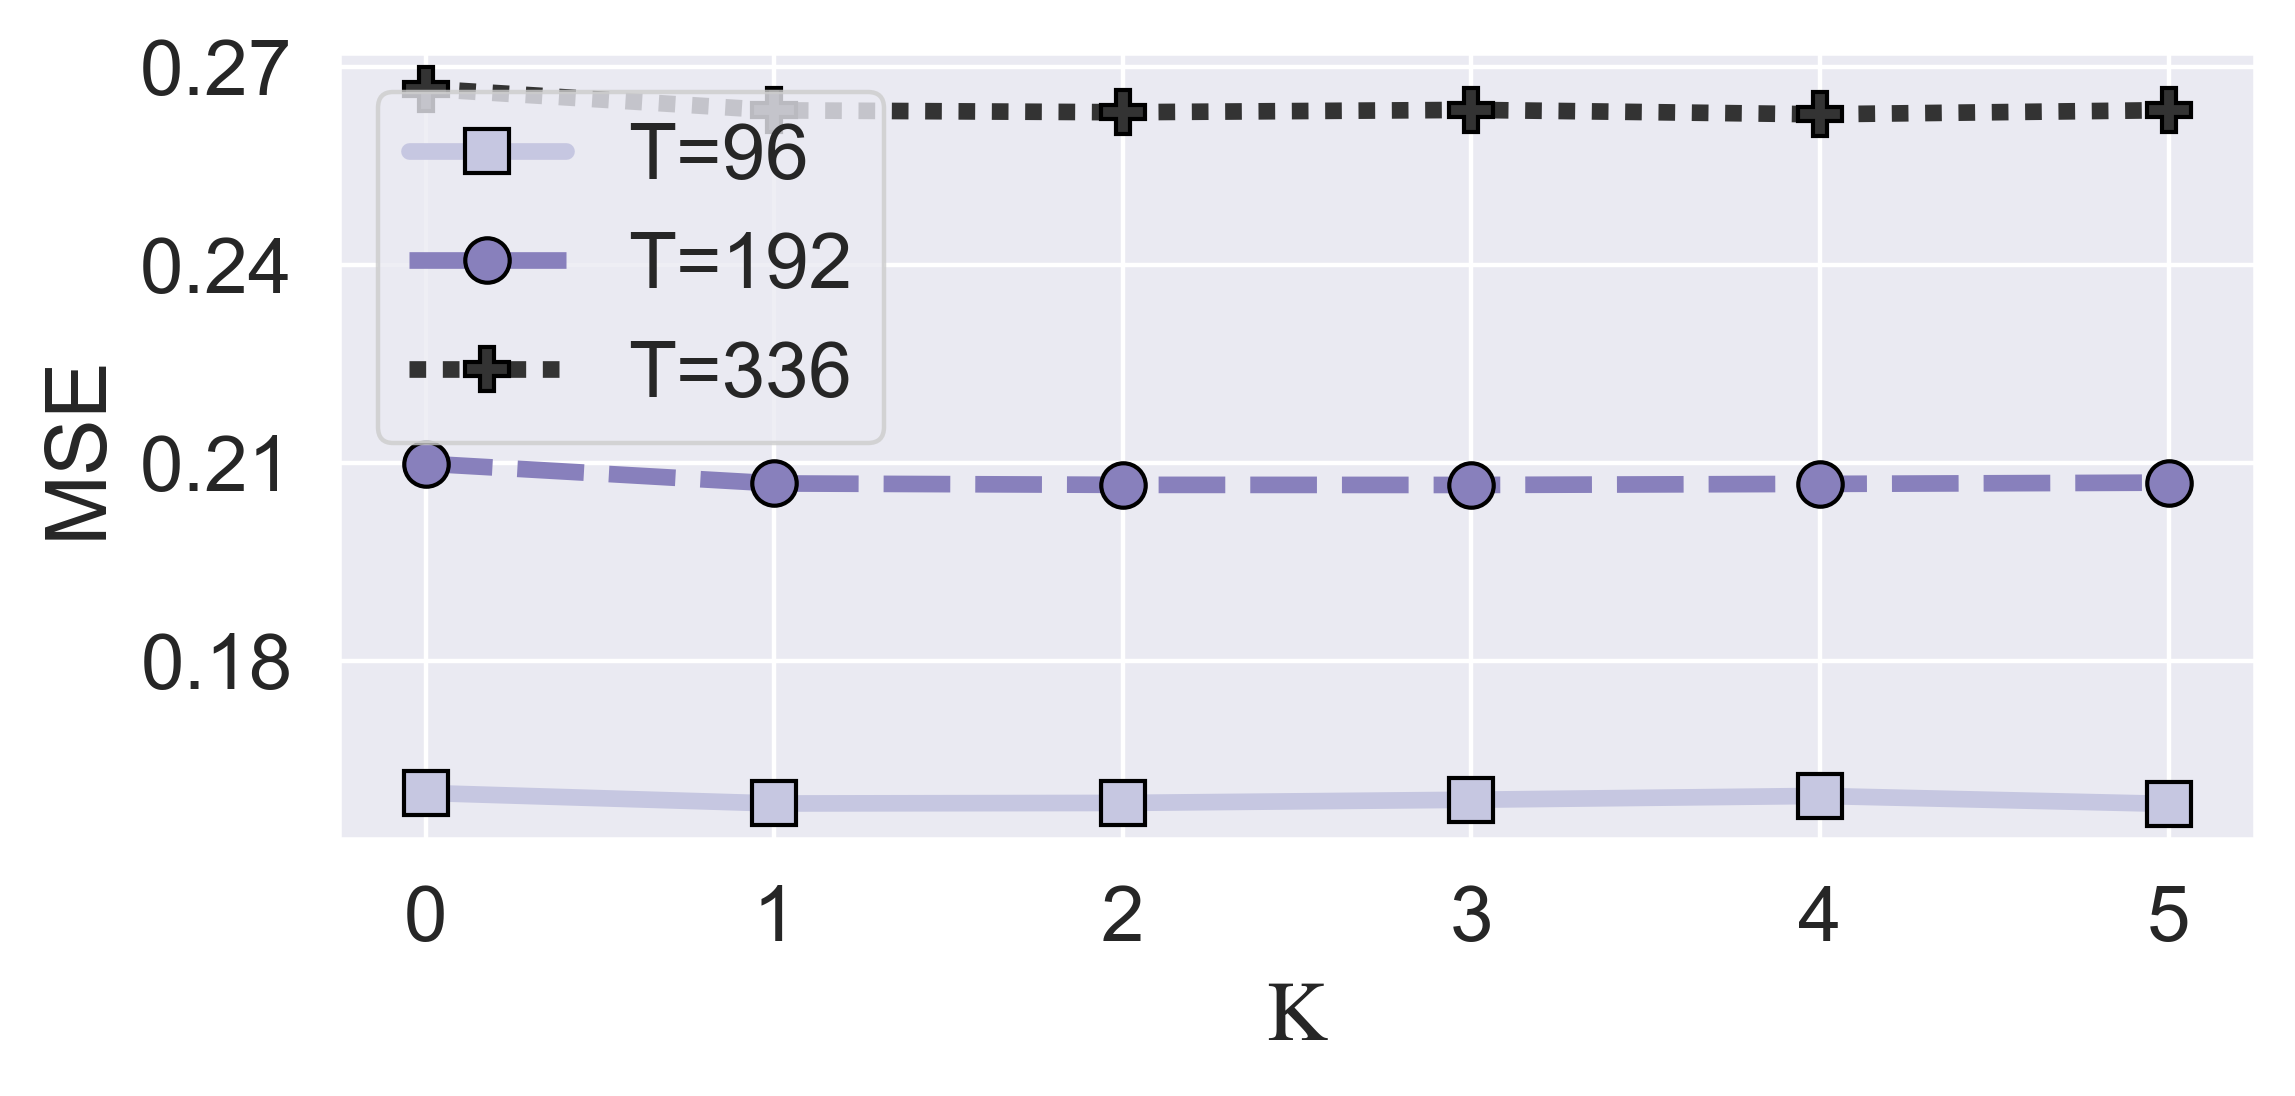

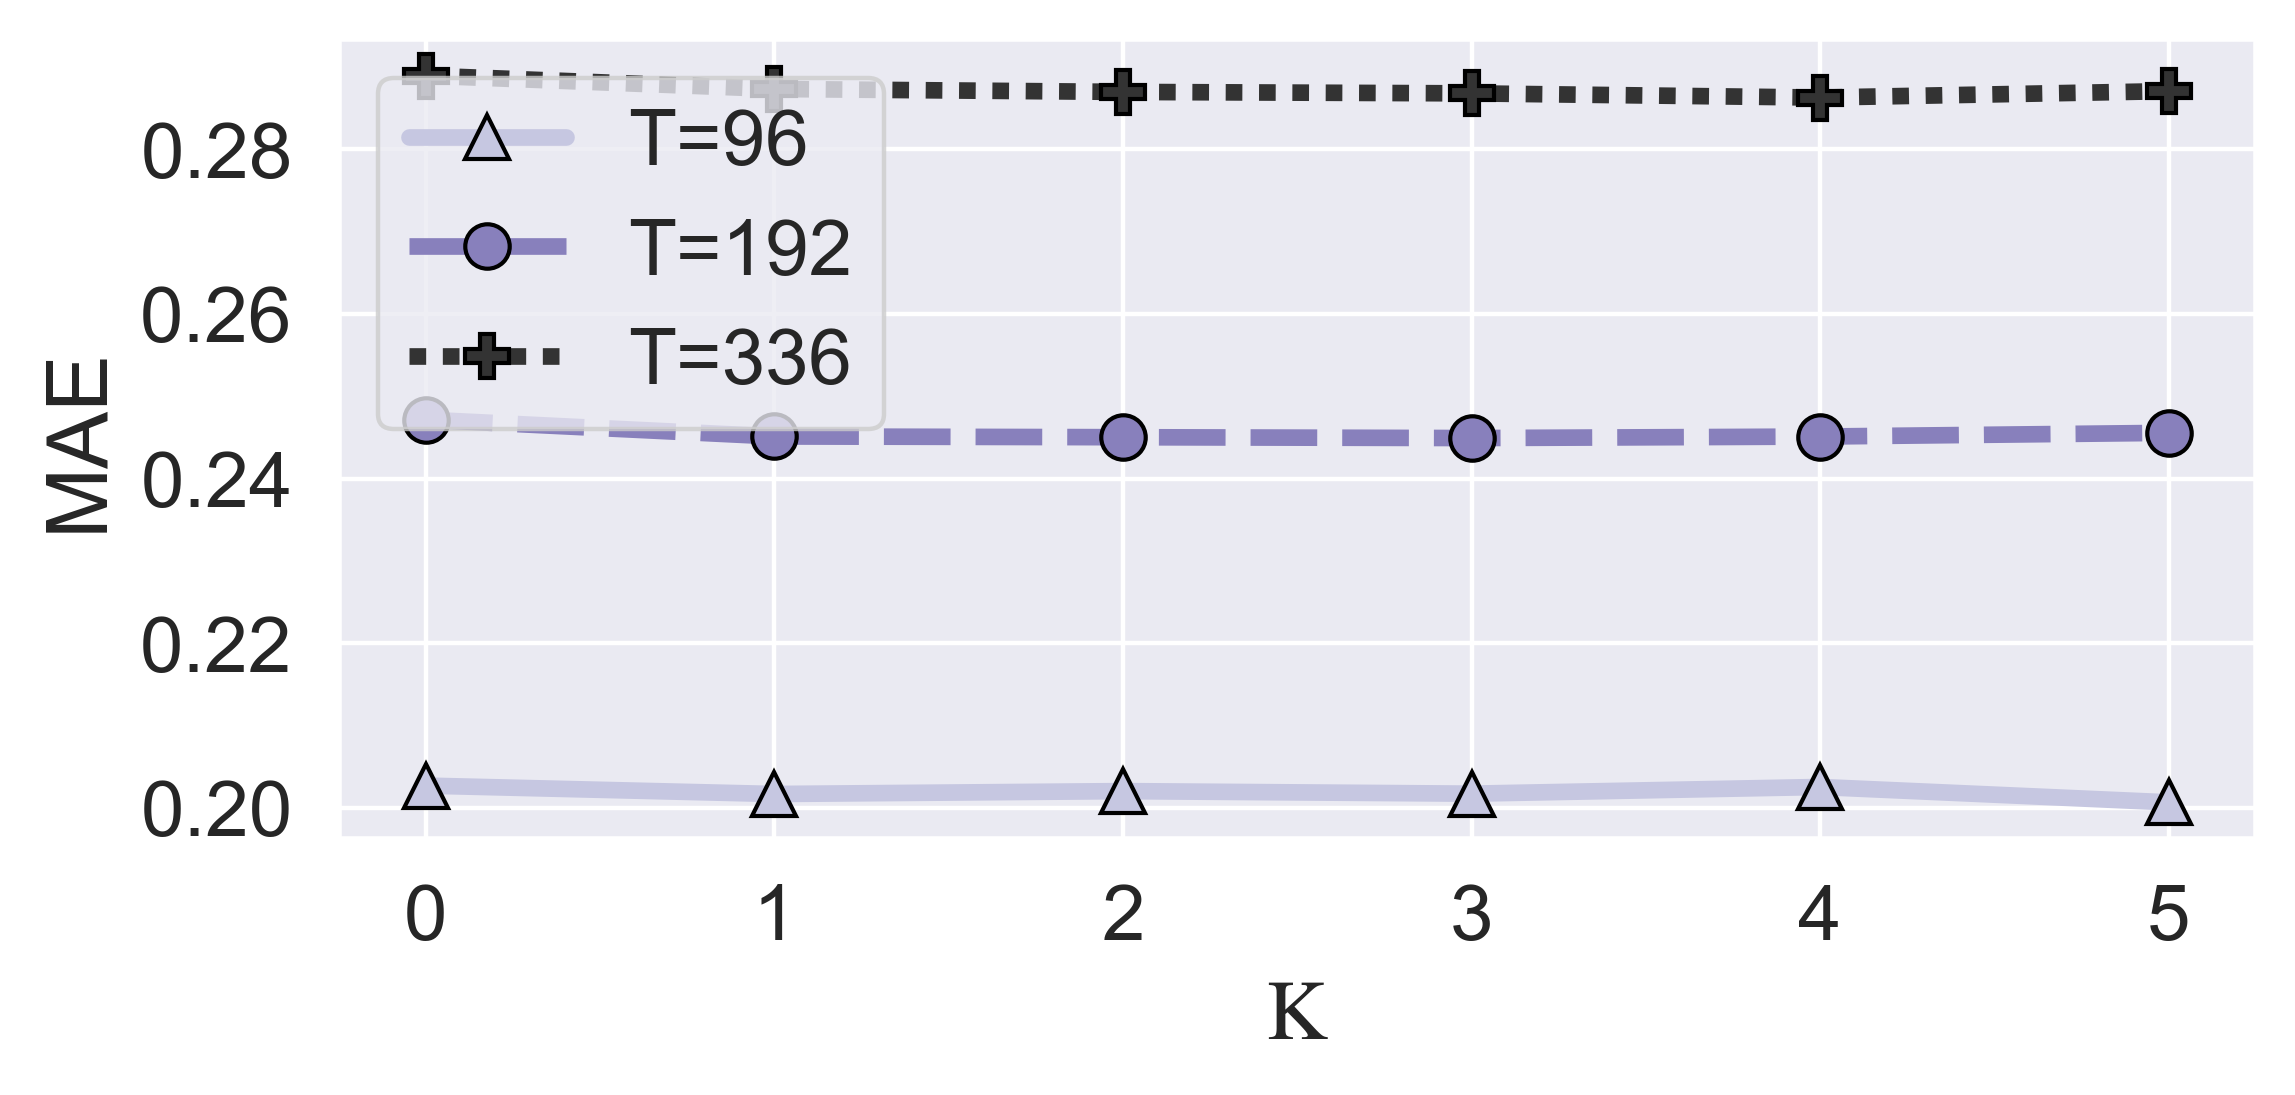

In [99]:
def plot(dataset, figure_name='figure', x='labda', x_name=r'$\lambda$', hue='p_noise', ytick1=None, ytick2=None, ypad1=None, ypad2=None, loc='upper left'):
    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    # dataset = dataset.sort_values(by=x)
    # dataset[x] = dataset[x].astype(str)

    f = plt.figure(dpi=400, figsize=(6,3)) # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1,1,1)
    sns.lineplot(x=x, y='mse', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")

    ax = plt.gca()
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=[r'T=96', r'T=192', r'T=336'], ncol=1, loc=loc)
    # plt.legend(handles=handles, ncol=2, loc=legend_location)
    if ytick1:
        plt.yticks(ytick1)
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    plt.ylabel('MSE')
    plt.xlabel(x_name)
    plt.tight_layout()
    with PdfPages(f"{figure_name}_MSE.pdf") as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)
    # plt.show()

    f = plt.figure(dpi=400, figsize=(6,3)) # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1,1,1)
    sns.lineplot(x=x, y='mae', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['^', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")

    ax = plt.gca()
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=[r'T=96', r'T=192', r'T=336'], ncol=1, loc=loc)
    # plt.yscale('log')
    if ytick2:
        plt.yticks(ytick2)
    if ypad2:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad2))  # 小数点后3位数间隔。
    plt.ylabel('MAE')
    plt.xlabel(x_name)
    plt.tight_layout()
    with PdfPages(f"{figure_name}_MAE.pdf") as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)
    # plt.show()


save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/figure_ML3'
os.makedirs(f"{save_root}/hparam", exist_ok=True)

datap = df_task.copy()
datap_ = datap[datap.data_id == 'ECL']
datap_ = datap_[datap_.pred_len.isin([96, 192, 336])]

save_name = f"{save_root}/hparam/ECL_K"
plot(datap_, x='num_tasks', hue='pred_len', figure_name=save_name, x_name=r"$\mathrm{K}$")


datap_ = datap[datap.data_id == 'Weather']
datap_ = datap_[datap_.pred_len.isin([96, 192, 336])]

save_name = f"{save_root}/hparam/Weather_K"
plot(datap_, x='num_tasks', hue='pred_len', figure_name=save_name, x_name=r"$\mathrm{K}$", ypad1=0.03)

# Varying meta lr

## load data

In [100]:
save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/stats_ML3'
log_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/logs'

baselines = pd.read_csv(f'{log_root}/baselines_chosen.csv')
finetunes_all = pd.read_csv(f'{save_root}/finetune_all_results.csv')
finetunes_all = finetunes_all[
    finetunes_all.meta_lr.isin([0.01, 0.02, 0.05, 0.1, 0.2]) &
    finetunes_all.meta_inner_steps.isin([1, 2, 3, 4, 5]) &
    finetunes_all.num_tasks.isin([1, 2, 3, 4, 5])
]

base = baselines.copy()
base = base[
    ((base.data_id == 'ETTh1') & (base.model == 'TQNet')) |
    ((base.data_id == 'ETTh2') & (base.model == 'TQNet')) |
    ((base.data_id == 'ETTm1') & (base.model == 'TQNet')) |
    ((base.data_id == 'ETTm2') & (base.model == 'TQNet')) |
    ((base.data_id == 'ECL') & (base.model == 'TQNet')) |
    ((base.data_id == 'Weather') & (base.model == 'TQNet'))
]
base['meta_lr'] = 0

hplr = finetunes_all.copy()
hplr = hplr[
    (hplr.meta_type == 'all')
]
hplr = hplr[
    ((hplr.data_id == 'ETTh1') & (hplr.model == 'TQNet')) |
    ((hplr.data_id == 'ETTh2') & (hplr.model == 'TQNet')) |
    ((hplr.data_id == 'ETTm1') & (hplr.model == 'TQNet')) |
    ((hplr.data_id == 'ETTm2') & (hplr.model == 'TQNet')) |
    ((hplr.data_id == 'ECL') & (hplr.model == 'TQNet')) |
    ((hplr.data_id == 'Weather') & (hplr.model == 'TQNet'))
]

In [57]:
for meta_lr in [0.01, 0.02, 0.05, 0.1, 0.2]:
    print(hps[(hps.data_id == 'ECL') & (hps.model == 'TQNet') & (hps.meta_lr == meta_lr)].pred_len.nunique(), hps[(hps.data_id == 'ECL') & (hps.model == 'TQNet') & (hps.meta_lr == meta_lr)].pred_len.unique())
    print(hps[(hps.data_id == 'Weather') & (hps.model == 'TQNet') & (hps.meta_lr == meta_lr)].pred_len.nunique())
    print()

# hplr.meta_lr.unique()

4 [ 96 192 336 720]
4

4 [ 96 192 336 720]
4

4 [ 96 192 336 720]
4

4 [ 96 192 336 720]
4

4 [ 96 192 336 720]
4



## preprocess main

In [101]:
df2 = hplr.copy()

df2 = df2[df2.meta_lr.isin([0.01, 0.02, 0.05, 0.1, 0.2])]
min_mse_idx = df2.groupby(['model', 'data_id', 'pred_len', 'meta_lr'])['mse'].idxmin()
df2 = df2.loc[min_mse_idx]

df3 = base.copy()

columns = ['model', 'data_id', 'pred_len', 'meta_lr', 'mse', 'mae']
df3 = df3[columns]
df2 = df2[columns]

df_lr = pd.concat([df3, df2], axis=0)

dst_order = ['ETTh1', 'ETTh2', 'ETTm1', 'ETTm2', 'ECL', 'Weather']
df_lr['data_id'] = pd.Categorical(df_lr['data_id'], categories=dst_order, ordered=True)

# df_step['alpha'] = df_step['alpha'].astype(float)

df_lr_avg = df_lr.groupby(['model', 'data_id', 'meta_lr']).mean(numeric_only=True).reset_index()
df_lr_avg['pred_len'] = 'Avg'

df_lr = pd.concat([df_lr, df_lr_avg]).reset_index(drop=True)
df_lr.sort_values(by=['model', 'data_id', 'meta_lr', 'pred_len'], inplace=True)

df_lr_avg

/tmp/ipykernel_482105/4115603019.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_lr_avg = df_lr.groupby(['model', 'data_id', 'meta_lr']).mean(numeric_only=True).reset_index()


,model,data_id,meta_lr,pred_len,mse,mae
0,TQNet,ETTh1,0.00,Avg,0.448900,0.438991
1,TQNet,ETTh1,0.01,Avg,0.432927,0.434106
2,TQNet,ETTh1,0.02,Avg,0.435644,0.432694
3,TQNet,ETTh1,0.05,Avg,0.435959,0.433154
4,TQNet,ETTh1,0.10,Avg,0.435806,0.432925
5,TQNet,ETTh1,0.20,Avg,0.436796,0.434692
6,TQNet,ETTh2,0.00,Avg,0.374594,0.400312
7,TQNet,ETTh2,0.01,Avg,0.372030,0.398736
8,TQNet,ETTh2,0.02,Avg,0.371716,0.398548
9,TQNet,ETTh2,0.05,Avg,0.370961,0.397887


## write to table

In [59]:
# 首先找出每个data_id的最小值和次小值位置
def find_best_and_second_best(df, data_ids, metric):
    best_worst_dict = {}
    
    for data_id in data_ids:
        data_subset = df[df['data_id'] == data_id]
        values = data_subset[metric].values
        meta_lr = data_subset['meta_lr'].values
        
        # 找到最小值和次小值的索引
        sorted_indices = np.argsort(values)
        best_lr = meta_lr[sorted_indices[0]]
        second_best_lr = meta_lr[sorted_indices[1]]
        
        best_worst_dict[data_id] = {
            'best': best_lr,
            'second_best': second_best_lr
        }
    
    return best_worst_dict

# 生成latex表格
def generate_latex_table(df_lr, data_ids=['ECL', 'Weather']):
    # 找出MSE和MAE的最小值和次小值位置
    mse_ranks = find_best_and_second_best(df_lr, data_ids, 'mse')
    mae_ranks = find_best_and_second_best(df_lr, data_ids, 'mae')
    
    contents = []
    
    for meta_lr in [0, 0.01, 0.02, 0.05, 0.1, 0.2]:
        line = f"{meta_lr} "
        
        for data_id in data_ids:
            _df = df_lr[
                (df_lr['meta_lr'] == meta_lr) &
                (df_lr['data_id'] == data_id) &
                (df_lr['pred_len'] == 'Avg')
            ]
            
            mse_val = _df['mse'].values[0]
            mae_val = _df['mae'].values[0]
            
            # 格式化MSE值
            if meta_lr == mse_ranks[data_id]['best']:
                mse_str = f"\\bst{{{mse_val:.4f}}}"
            elif meta_lr == mse_ranks[data_id]['second_best']:
                mse_str = f"\\subbst{{{mse_val:.4f}}}"
            else:
                mse_str = f"{mse_val:.4f}"
            
            # 格式化MAE值
            if meta_lr == mae_ranks[data_id]['best']:
                mae_str = f"\\bst{{{mae_val:.4f}}}"
            elif meta_lr == mae_ranks[data_id]['second_best']:
                mae_str = f"\\subbst{{{mae_val:.4f}}}"
            else:
                mae_str = f"{mae_val:.4f}"
            
            line += f"& {mse_str} & {mae_str} "
        
        line += r"\\"
        contents.append(line)
    
    return "\n".join(contents)

latex_table = generate_latex_table(df_lr_avg)
print(latex_table)


0 & 0.1750 & 0.2655 & 0.2457 & 0.2703 \\
0.01 & 0.1657 & 0.2577 & 0.2429 & 0.2687 \\
0.02 & 0.1649 & 0.2571 & \subbst{0.2427} & 0.2683 \\
0.05 & \subbst{0.1648} & \subbst{0.2567} & \bst{0.2427} & \bst{0.2681} \\
0.1 & \bst{0.1647} & \bst{0.2566} & 0.2430 & 0.2683 \\
0.2 & 0.1655 & 0.2571 & 0.2431 & \subbst{0.2683} \\


## plot main

/tmp/ipykernel_482105/4251592673.py:14: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(x=x, y='mse', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")
/tmp/ipykernel_482105/4251592673.py:34: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(x=x, y='mae', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['^', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")
/tmp/ipykernel_482105/4251592673.py:14: UserWarning: The markers list has more values (4) than needed (3), which may not be intended.
  sns.lineplot(x=x, y='mse', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")
/tmp/ipykernel_482105/4251592673.py:34: Use

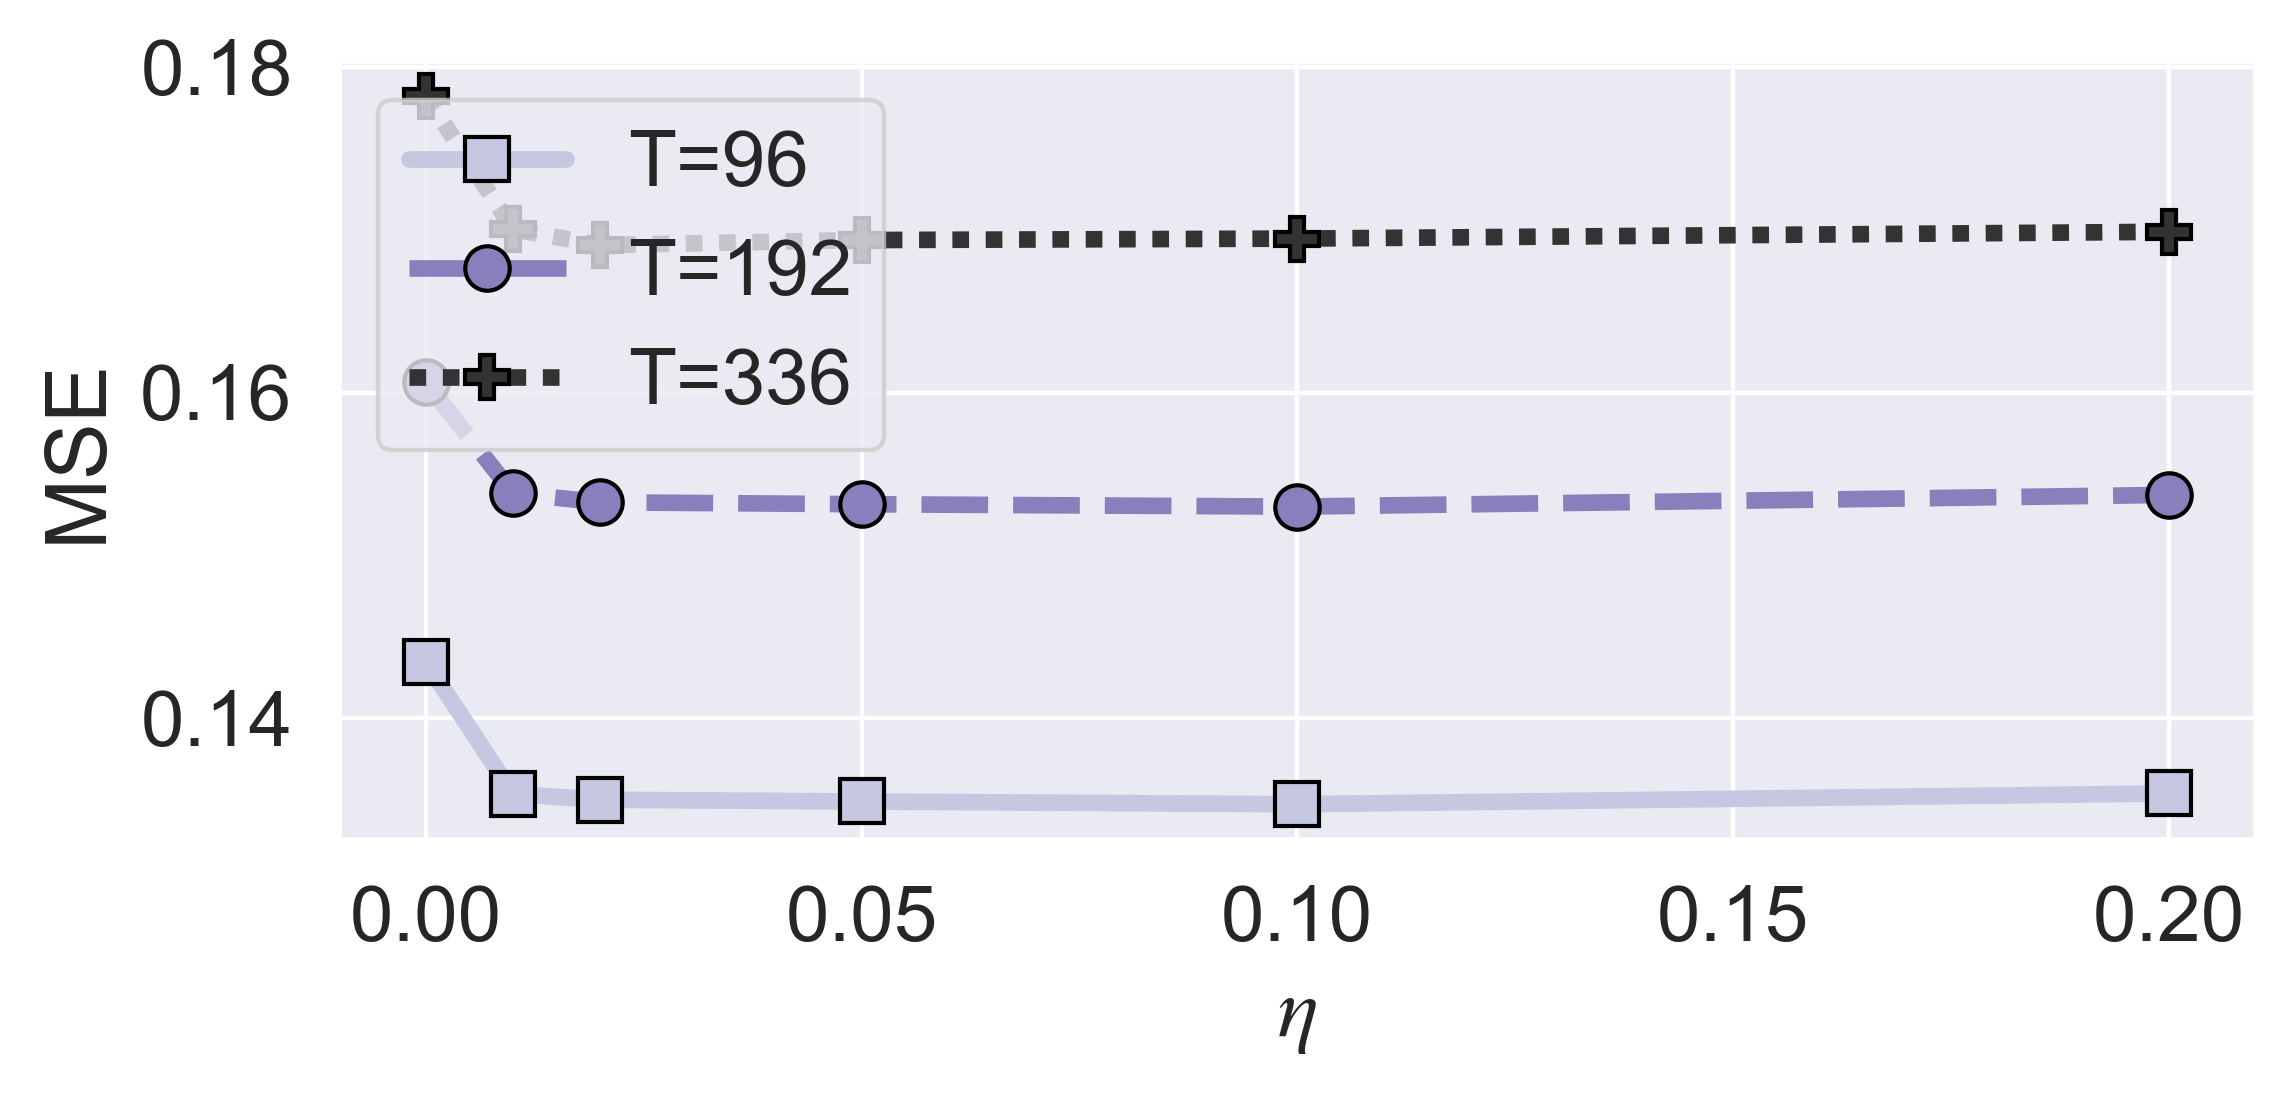

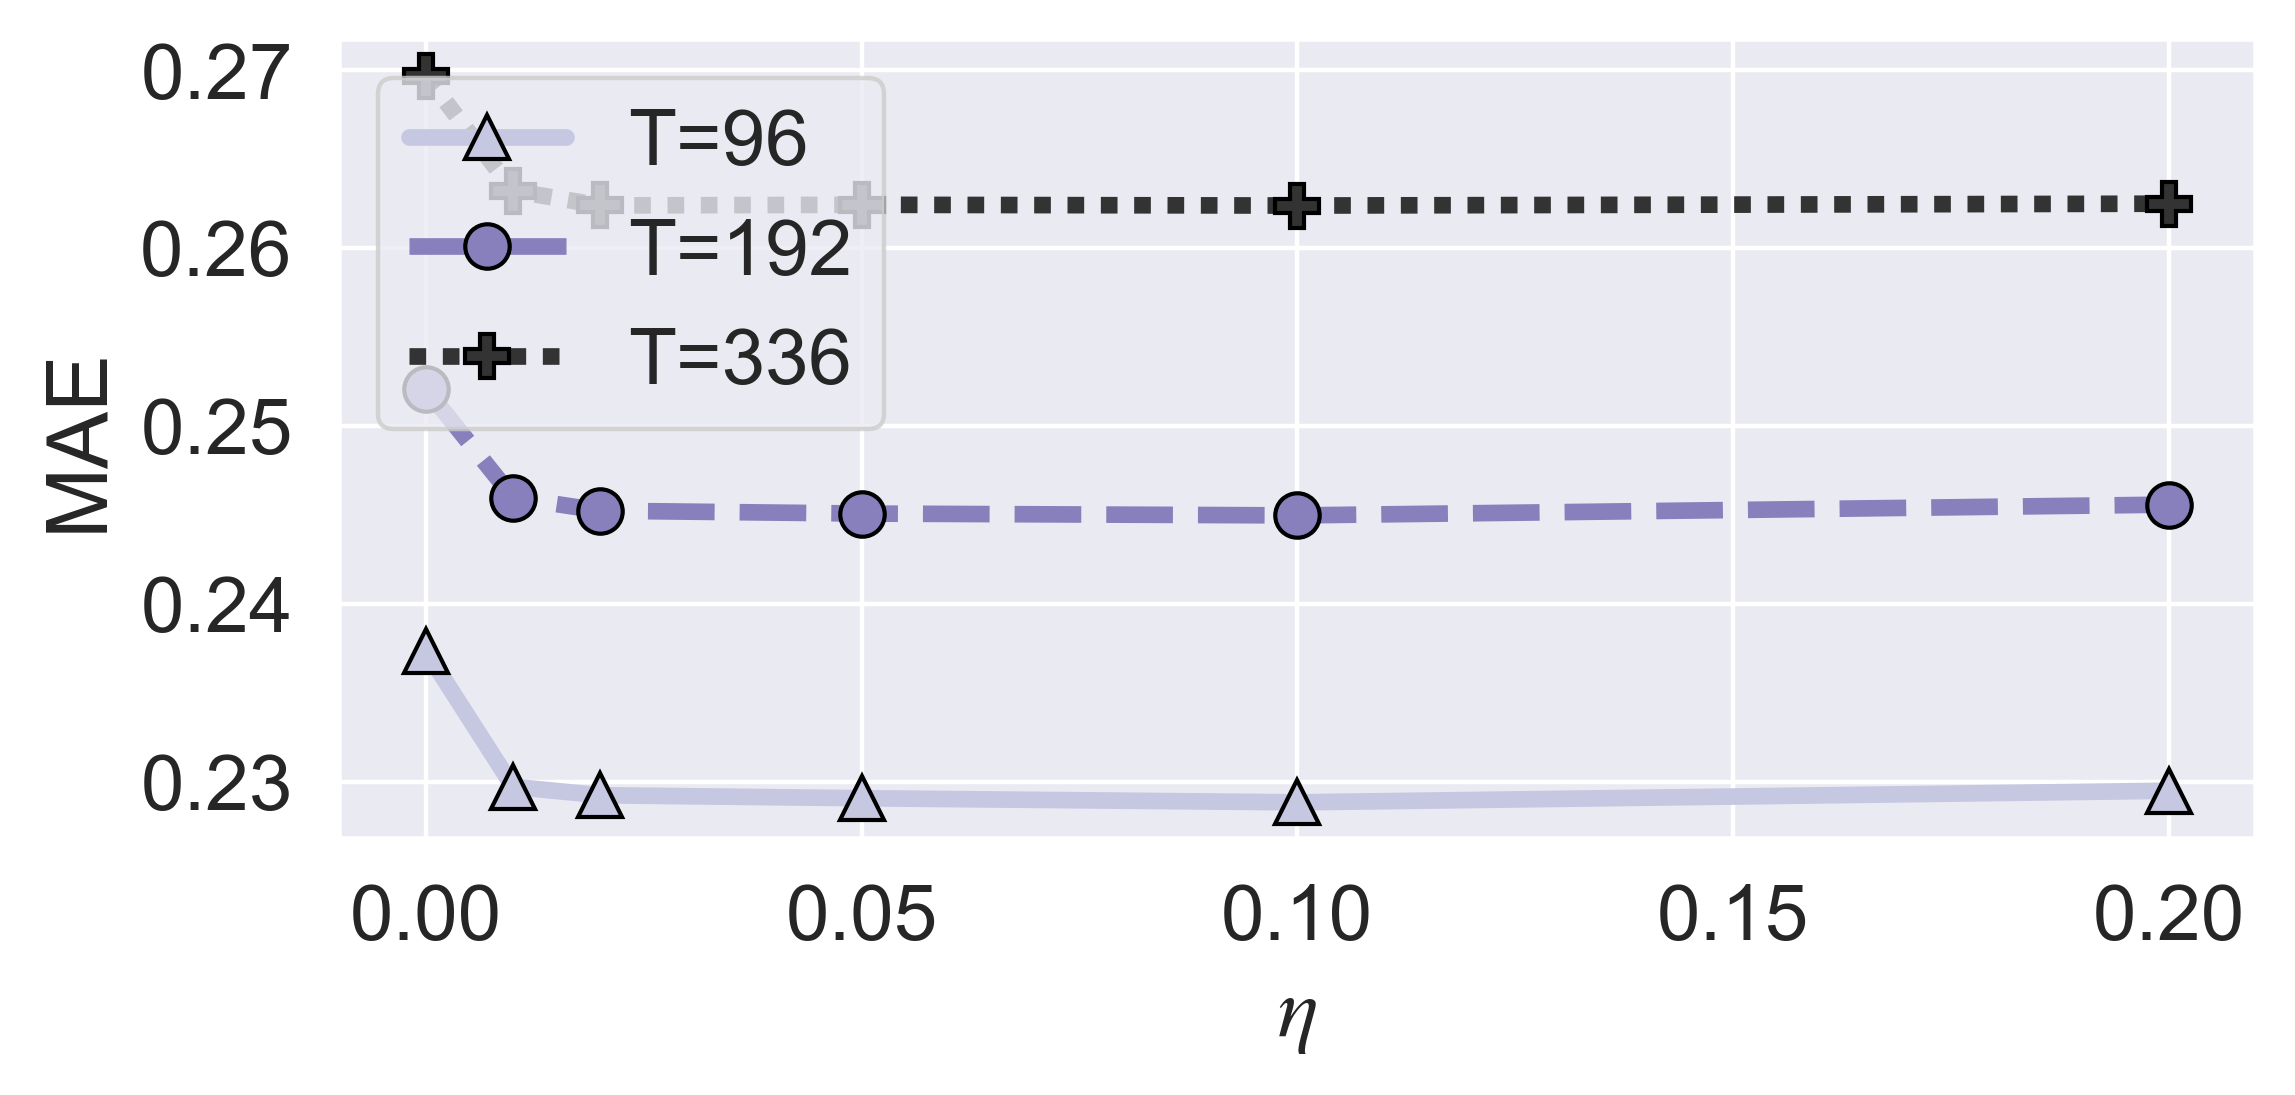

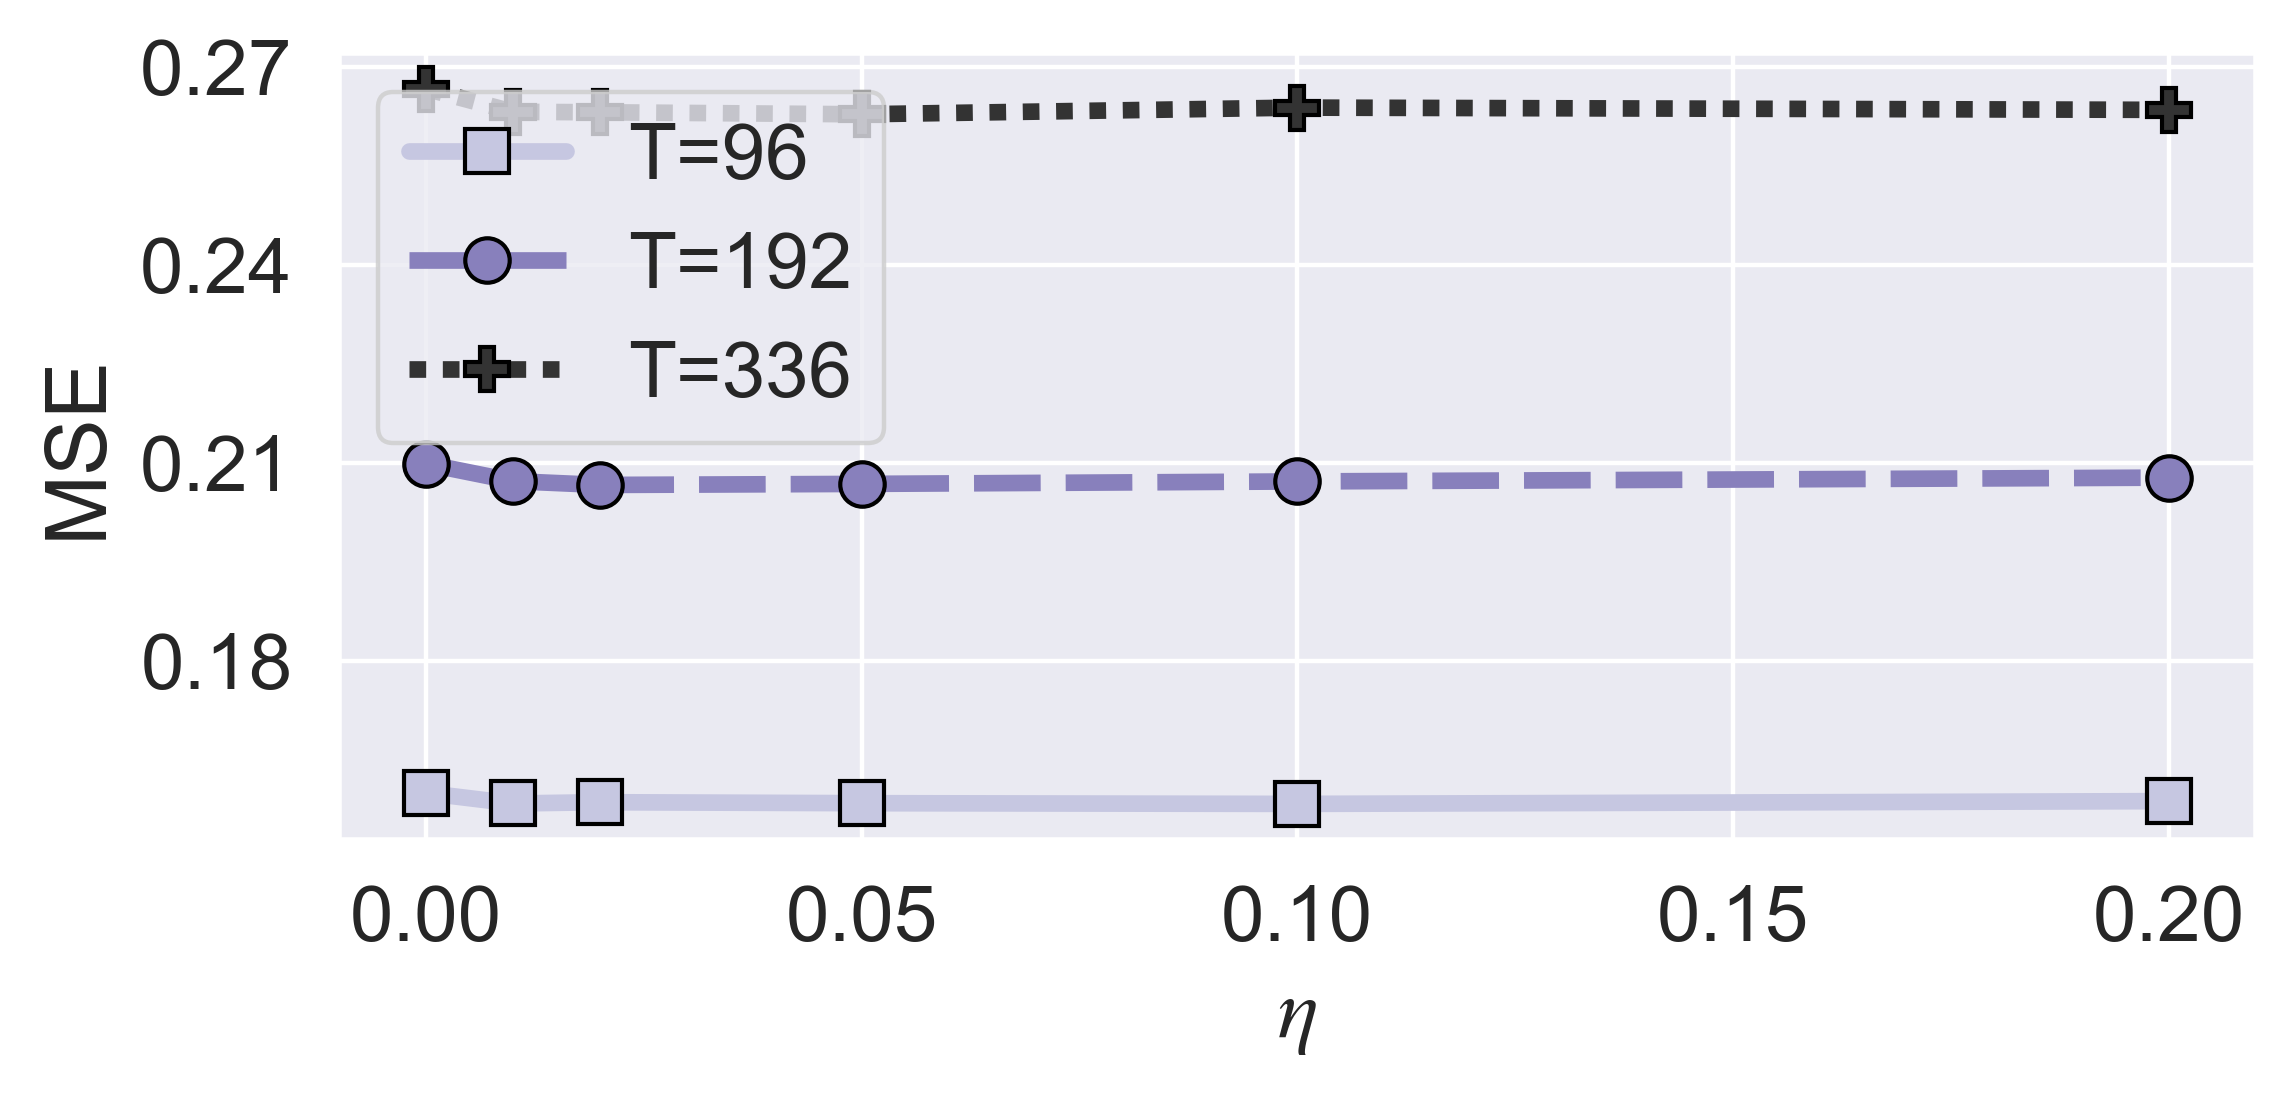

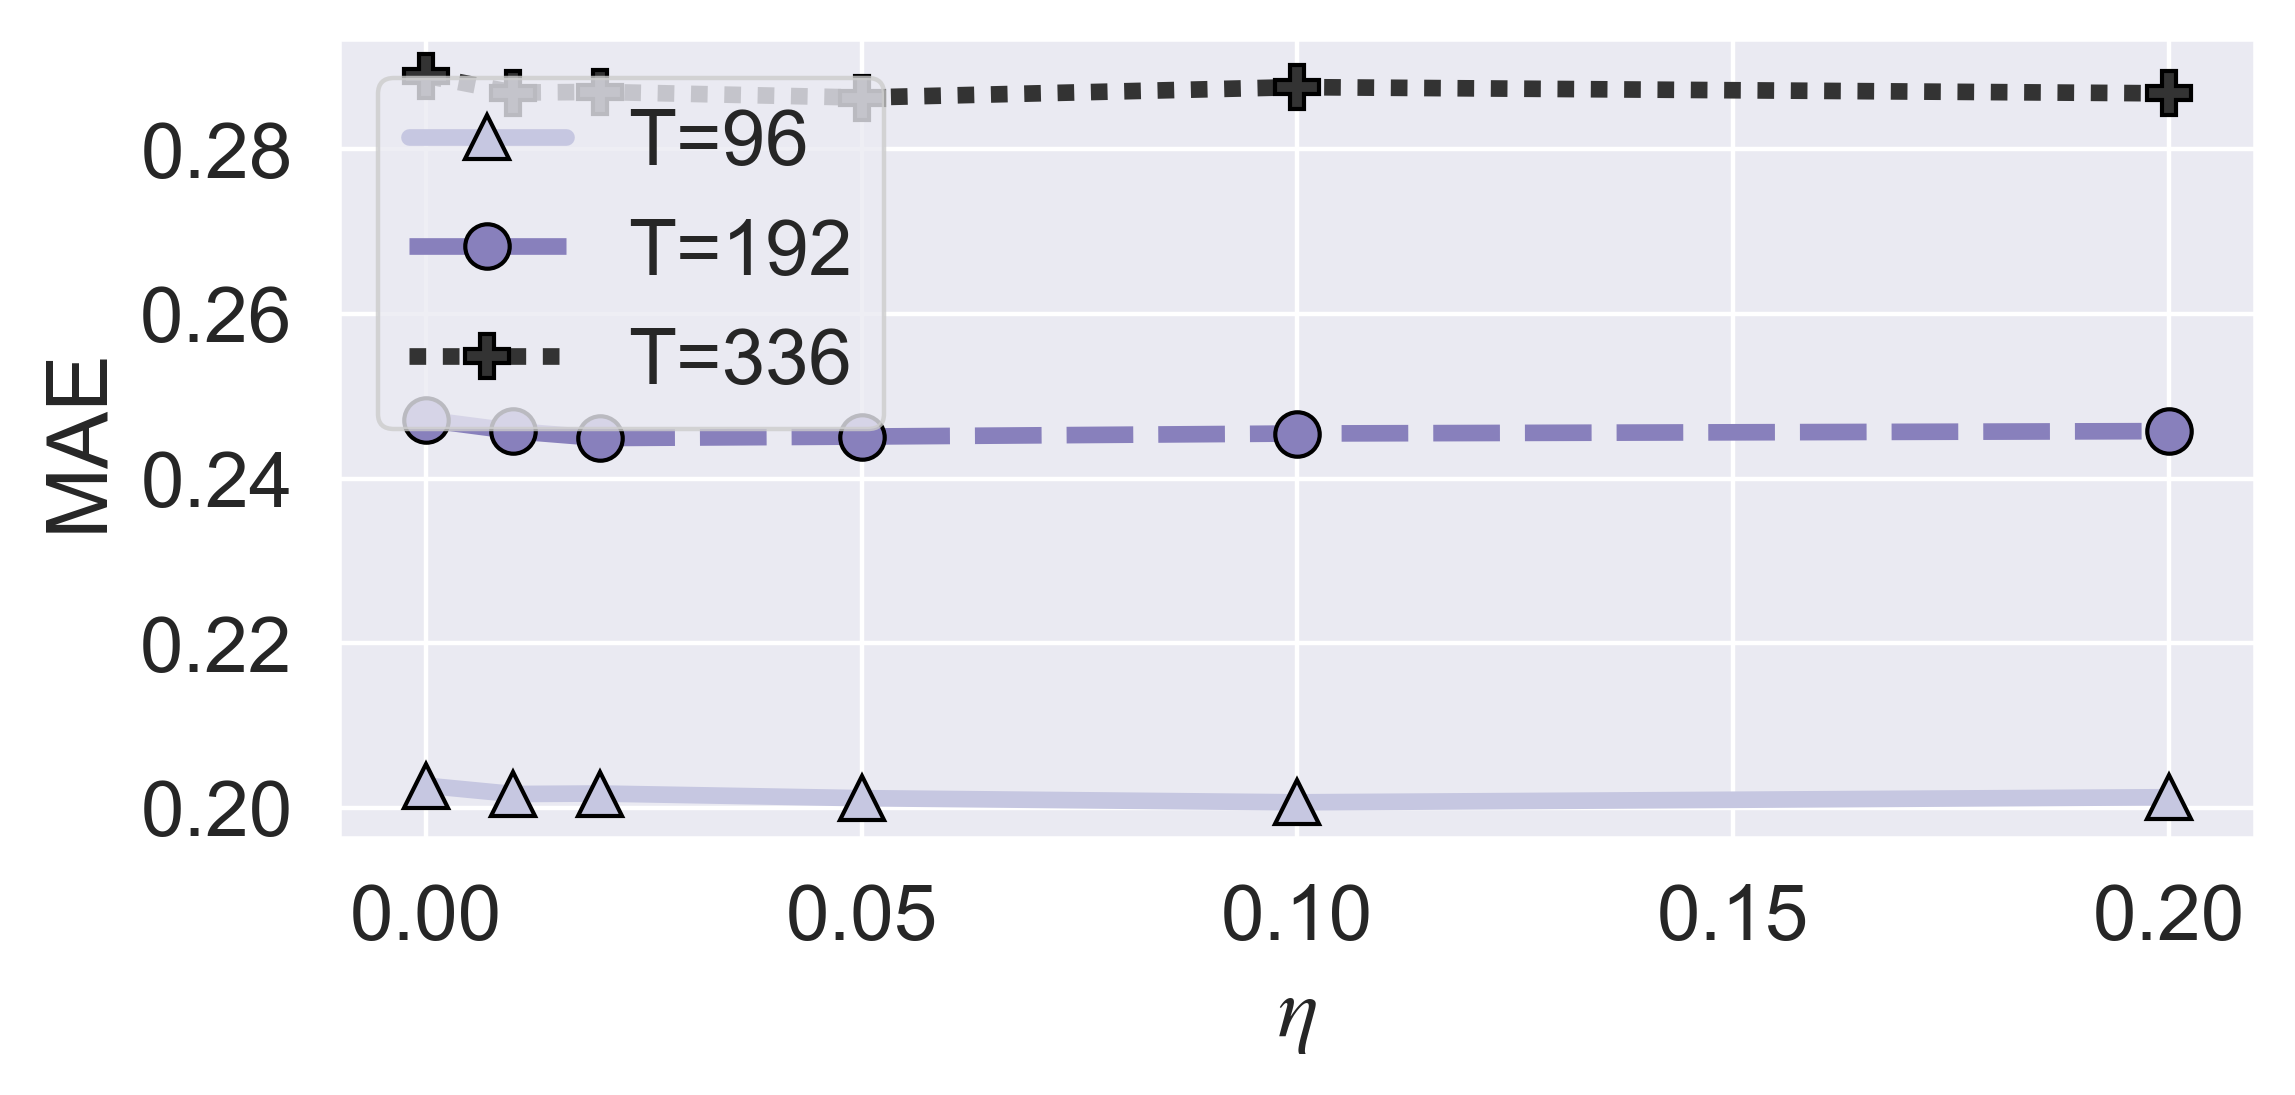

In [105]:
def plot(dataset, figure_name='figure', x='labda', x_name=r'$\lambda$', hue='p_noise', ytick1=None, ytick2=None, ypad1=None, ypad2=None, loc='upper left'):
    style = ['darkgrid', 'dark', 'white', 'whitegrid', 'ticks']
    context = ['paper', 'notebook', 'talk', 'poster']
    palette = sns.color_palette('deep')
    palette = [palette[3], palette[0], palette[2]] + palette[4:]
    sns.set_theme(style=style[0], context=context[0], font='Arial', font_scale=1.6, palette=[palette[0], palette[3], palette[2]] + palette[4:])

    # dataset = dataset.sort_values(by=x)
    # dataset[x] = dataset[x].astype(str)

    f = plt.figure(dpi=400, figsize=(6,3)) # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1,1,1)
    sns.lineplot(x=x, y='mse', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['s', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")

    ax = plt.gca()
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=[r'T=96', r'T=192', r'T=336'], ncol=1, loc=loc)
    # plt.legend(handles=handles, ncol=2, loc=legend_location)
    if ytick1:
        plt.yticks(ytick1)
    if ypad1:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad1))  # 小数点后3位数间隔。
    plt.ylabel('MSE')
    plt.xlabel(x_name)
    plt.tight_layout()
    with PdfPages(f"{figure_name}_MSE.pdf") as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)
    # plt.show()

    f = plt.figure(dpi=400, figsize=(6,3)) # 如果只画一条线，就用红色，高改为3->2.5
    f.subplots_adjust(top=0.9, left=0.1, right=0.9, bottom=0.2)
    f.add_subplot(1,1,1)
    sns.lineplot(x=x, y='mae', hue=hue, data=dataset, style=hue, errorbar=('ci', 99.9), markers=['^', 'o', "P", "*"], linewidth=3, markersize=8, markeredgecolor='k', palette="Purples_d")

    ax = plt.gca()
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(handles=handles, labels=[r'T=96', r'T=192', r'T=336'], ncol=1, loc=loc)
    # plt.xscale('log', base=2)
    if ytick2:
        plt.yticks(ytick2)
    if ypad2:
        ax.yaxis.set_major_locator(plt.MultipleLocator(ypad2))  # 小数点后3位数间隔。
    plt.ylabel('MAE')
    plt.xlabel(x_name)
    plt.tight_layout()
    with PdfPages(f"{figure_name}_MAE.pdf") as pdf:
        pdf.savefig(f, bbox_inches='tight', pad_inches=0.01)
    # plt.show()


save_root = '/mnt/tidalfs-bdsz01/usr/panlicheng/workspace/ProjDF-Meta/figure_ML3'
os.makedirs(f"{save_root}/hparam", exist_ok=True)

datap = df_lr.copy()
datap_ = datap[datap.data_id == 'ECL']
datap_ = datap_[datap_.pred_len.isin([96, 192, 336])]

save_name = f"{save_root}/hparam/ECL_eta"
plot(datap_, x='meta_lr', hue='pred_len', figure_name=save_name, x_name=r"$\eta$")


datap_ = datap[datap.data_id == 'Weather']
datap_ = datap_[datap_.pred_len.isin([96, 192, 336])]

save_name = f"{save_root}/hparam/Weather_eta"
plot(datap_, x='meta_lr', hue='pred_len', figure_name=save_name, x_name=r"$\eta$", ypad1=0.03)